# MATH-Perturb cross-ablation analysis

Five MATH-Perturb evaluation runs, compared: figures, tables and paired statistical
tests for the results chapter.

Every problem is **MATH Level 5**, paired with two perturbations:

* **simple** — surface change; the original solution method still applies
* **hard** — structural change; the original method no longer applies

The benchmark's memorisation claim is a *three-way pattern*, not a raw accuracy drop:
a model relying on memorised **techniques** rather than reasoning solves the original,
solves the simple perturbation (the technique still works), and fails the hard one
(it applies the technique anyway). Figure 6 makes that pattern explicit.

| | training data | objective | on the γ path? |
|---|---|---|---|
| **A0** | none (base `Qwen2.5-Math-1.5B`) | — | no |
| **A1** | originals only | GRPO | no — different data |
| **A2** | originals + all variants | GRPO | **yes, γ = 1** |
| **A3 (γ=1.5)** | originals + all variants | GRPO + GRIP | **yes, γ = 1.5** |
| **A3** | originals + all variants | GRPO + GRIP | **yes, γ = 2** |

* **A1 → A2** isolates *data augmentation*. **A2 → A3** isolates *the objective* —
  same data, same hyperparameters, only the invariance penalty differs. That is the
  thesis test.
* **A2 → A3 (γ=1.5) → A3 (γ=2)** is the **γ path**: one estimator at three penalty
  strengths. The intermediate run turns a two-point comparison into a dose–response,
  which is what Figure 13 shows. In code the γ = 1.5 run is keyed `A3g1.5`.

**Figures show point estimates only.** Error bars were removed to keep five-run grouped
figures readable. The uncertainty is not dropped: every figure prints its 95%
cluster-bootstrap intervals beneath it, Tables 1 and 3 carry them, and every claim of a
difference rests on the paired tests in §5 — overlapping or non-overlapping whiskers were
never the test anyway.

### Data findings established before any figure was drawn

1. **All five runs are internally consistent.** Each `summary.json` reproduces exactly
   (to 1e-9) from its own `items.jsonl` and `groups.jsonl`. Zero NaNs in `gap_mean`,
   `within_var`, `c_corr`, `acc_original`; zero groups with `n_perturbed_scored == 0`;
   all 834 items per run at `n_attempted = 8`.
2. **A3 no longer matches the brief's headline table, and the loader is not at fault.**
   A3 was **re-evaluated from scratch on 2026-09-18** (manifest start 20:09, generations
   21:21, verification 21:47, aggregation 22:26) — after the brief was written. A0, A1
   and A2 still match the brief exactly. Same checkpoint, same seed, same vLLM build and
   sampling settings, so the differences are **eval-rerun nondeterminism**, quantified in
   §2 and used later to calibrate how much of a small A3 contrast is real.
3. **A0 has 277 groups; A1/A2/A3 have 278.** Group `2184` (Prealgebra) had all 8 of its
   *original* samples fail answer extraction, so the aggregation dropped the seed under
   its documented `original_unscorable` rule. Correct behaviour. Every cross-run
   statistic here runs on the **277 shared seeds**.
4. A side effect of (3): A0's shipped `acc_by_arm` averages `original` over 277 items but
   `simple` and `hard` over 278. This notebook recomputes accuracy on the aligned seed
   set so the arms share a denominator.
5. **G-Pass@8 is available for all three arms** (every item has 8 attempts), so the
   reliability profile is complete — unlike the ASyMOB runs, where variants were sampled
   once.
6. **Recovery rates are substantial (0.13–0.22), not near zero.** The brief asks for this
   to be flagged; §Fig 5 does so and explains why it is structural here rather than a
   data fault.
7. `c_ans` is **excluded**: the three arms have different correct answers by
   construction, so answer agreement carries no signal. Present in `groups.jsonl`,
   deliberately unused.
8. **The γ = 1.5 run** (`a3_mathperturb_g15_20260918`, checkpoint `a3_grpo_grip_g1.5`,
   evaluated 2026-09-19) postdates the brief, so it has no row in the brief's headline
   table. It was checked the same way as the others: same `metrics.py` and
   `aggregate_mathperturb.py`, same data file, seed and sampling settings, 278 groups with
   group `2184` present (so it shares all 277 aligned seeds), no NaNs, and a
   `summary.json` that reproduces from its own raw files.

In [1]:
import os, sys, json, math, glob, textwrap, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# The repository root is found by walking up from the working directory, so the
# notebook can be run from anywhere in the repo without absolute paths.
def _repo_root():
    here = Path(os.getcwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "ablations").is_dir() and (candidate / "README.md").is_file():
            return candidate
    raise RuntimeError("repository root not found: expected a parent directory "
                       "containing both ablations/ and README.md")

REPO   = _repo_root()
BASE   = str(REPO / "ablations" / "eval" / "math_perturb")
FIGDIR = os.path.join(BASE, "figures")
os.makedirs(FIGDIR, exist_ok=True)

RUNS = {
    "A0": f"{BASE}/a0_mathperturb_1.5B_20260904",   # untrained Qwen2.5-Math-1.5B
    "A1": f"{BASE}/a1_mathperturb_20260915",        # GRPO, originals only
    "A2": f"{BASE}/a2_mathperturb_20260915",        # GRPO, originals + variants  (gamma = 1)
    "A3g1.5": f"{BASE}/a3_mathperturb_gamma1.5_20260918",  # GRPO + GRIP, gamma = 1.5
    "A3": f"{BASE}/a3_mathperturb_gamma2_20260915",        # GRPO + GRIP, gamma = 2
}
ORDER = ["A0", "A1", "A2", "A3g1.5", "A3"]         # gamma-path runs in increasing gamma

# The gamma path: one estimator (GRPO + GRIP on augmented data) at increasing gamma.
# gamma = 1 is plain GRPO (A2). Adding another gamma is one entry here plus one in RUNS.
GAMMA_PATH = {1.0: "A2", 1.5: "A3g1.5", 2.0: "A3"}
ARMS  = ["original", "simple", "hard"]
PERT  = ["simple", "hard"]

LABEL = {"A0": "A0  base (untrained)",
         "A1": "A1  GRPO, originals",
         "A2": "A2  GRPO, augmented  ($\\gamma$=1)",
         "A3g1.5": "A3  GRPO+GRIP  ($\\gamma$=1.5)",
         "A3": "A3  GRPO+GRIP  ($\\gamma$=2)"}
SHORT = {"A0": "A0", "A1": "A1", "A2": "A2 ($\\gamma$=1)",
         "A3g1.5": "A3 ($\\gamma$=1.5)", "A3": "A3 ($\\gamma$=2)"}

# A0 grey, A1 green. The gamma-path runs share one hue, light -> dark with increasing
# gamma, so the path reads as a single estimator. A3 (gamma = 2) is the strongest colour.
COLOR = {"A0": "#9E9E9E", "A1": "#66A182", "A2": "#6BAED6", "A3g1.5": "#2F74B5", "A3": "#08306B"}

# Grouped-bar geometry scales with the number of runs.
BW = 0.8 / len(ORDER)
def boff(i):
    return (i - (len(ORDER) - 1) / 2) * BW

B_BOOT, SEED = 10_000, 0

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9.5, "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
pd.set_option("display.width", 220, "display.max_columns", 60)

def savefig(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(FIGDIR, f"{name}.{ext}"), dpi=300)
    print(f"saved  {FIGDIR}/{name}.{{pdf,png}}")

RESULTS = {}
print("figures ->", FIGDIR)

figures -> /home/amz/projects/GRIP/ablations/eval/math_perturb/figures


---
## 1. Loading

Runs are located by globbing `**/summary.json` rather than hardcoding depth. A missing
run raises with the attempted path — an ablation is never silently skipped.

In [2]:
def _jsonl(path):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))   # json.loads accepts bare NaN
    return rows


def _locate(run_dir, filename, required=True):
    '''Glob for a file anywhere under run_dir. Fail loudly with the attempted path.'''
    pattern = os.path.join(run_dir, "**", filename)
    hits = sorted(glob.glob(pattern, recursive=True))
    if not hits:
        if required:
            raise FileNotFoundError(
                f"required file not found\n  looked for : {pattern}\n"
                f"  run dir    : {run_dir} (exists={os.path.isdir(run_dir)})")
        return None
    if len(hits) > 1:
        print(f"  ! {len(hits)} matches for {filename}, using {hits[0]}")
    return hits[0]


def load_runs(runs=RUNS):
    data = {}
    for key, run_dir in runs.items():
        if not os.path.isdir(run_dir):
            raise FileNotFoundError(f"[{key}] run directory missing: {run_dir}")

        s_path = _locate(run_dir, "summary.json")
        g_path = _locate(run_dir, "groups.jsonl")
        i_path = _locate(run_dir, "items.jsonl")
        m_path = _locate(run_dir, "manifest.json", required=False)
        eval_dir = os.path.dirname(s_path)

        groups_raw = _jsonl(g_path)
        data[key] = {
            "summary": json.load(open(s_path)),
            "groups": pd.DataFrame(groups_raw),
            "groups_raw": groups_raw,
            "items": pd.DataFrame(_jsonl(i_path)),
            "manifest": json.load(open(m_path)) if m_path else {},
            "eval_dir": eval_dir,
        }
        print(f"[{key}] {len(groups_raw):>4} groups   {len(data[key]['items']):>5} items   {eval_dir}")
    return data


data = load_runs()

[A0]  277 groups     834 items   /home/amz/projects/GRIP/ablations/eval/math_perturb/a0_mathperturb_1.5B_20260904/eval/MATH_Perturb
[A1]  278 groups     834 items   /home/amz/projects/GRIP/ablations/eval/math_perturb/a1_mathperturb_20260915/eval/MATH_Perturb
[A2]  278 groups     834 items   /home/amz/projects/GRIP/ablations/eval/math_perturb/a2_mathperturb_20260915/eval/MATH_Perturb
[A3g1.5]  278 groups     834 items   /home/amz/projects/GRIP/ablations/eval/math_perturb/a3_mathperturb_gamma1.5_20260918/eval/MATH_Perturb
[A3]  278 groups     834 items   /home/amz/projects/GRIP/ablations/eval/math_perturb/a3_mathperturb_gamma2_20260915/eval/MATH_Perturb


In [3]:
# Run identity. The `ablation` field reads "a0" in every manifest, which is a
# mislabel, so identity comes from the checkpoint path. Timestamps matter here:
# see the A3 re-run note in the header.
rows = []
for k in ORDER:
    m = data[k]["manifest"]; g = m.get("generation", {})
    ck = m.get("model", {}).get("name", "?")
    rows.append({"run": k, "run_id": m.get("run_id", "?"),
                 "manifest.ablation": m.get("ablation", "?"),
                 "checkpoint": os.path.basename(os.path.dirname(ck.rstrip("/"))) or ck,
                 "eval started": m.get("timestamp_start", "?")[:19],
                 "vllm": m.get("vllm_version", "?"),
                 "temp": g.get("temperature"), "max_new": g.get("max_new_tokens"),
                 "seed": m.get("global_seed")})
IDENT = pd.DataFrame(rows).set_index("run")
print(IDENT.to_string())

if IDENT["manifest.ablation"].nunique() == 1:
    print("\n! manifest.ablation is identical across all runs -- MISLABELLED. "
          "Runs identified by checkpoint path instead.")
same = IDENT[["vllm", "temp", "max_new", "seed"]].drop_duplicates()
print(f"generation settings identical across runs: {len(same) == 1}")
RESULTS["identity"] = IDENT.reset_index().to_dict("records")

                              run_id manifest.ablation            checkpoint         eval started    vllm  temp  max_new  seed
run                                                                                                                           
A0      a0_mathperturb_20260904_1.5B                a0                  Qwen  2026-09-05T00:54:01  0.26.0   0.6     3072    42
A1           a1_mathperturb_20260915                a0  a1_grpo_originals_v3  2026-09-17T03:08:54  0.26.0   0.6     3072    42
A2           a2_mathperturb_20260915                a0  a2_grpo_augmented_v3  2026-09-17T03:26:22  0.26.0   0.6     3072    42
A3g1.5   a3_mathperturb_g15_20260918                a0     a3_grpo_grip_g1.5  2026-09-19T18:10:25  0.26.0   0.6     3072    42
A3           a3_mathperturb_20260915                a0       a3_grpo_grip_g2  2026-09-18T20:09:12  0.26.0   0.6     3072    42

! manifest.ablation is identical across all runs -- MISLABELLED. Runs identified by checkpoint path instead.
g

---
## 2. Sanity check against the brief's headline table

The brief supplies precomputed headline numbers and says that a loader disagreeing with
them is wrong. That check is run here rather than assumed — and it does **not** pass
uniformly, so the cause is established before anything is built on top of it.

In [4]:
BRIEF = pd.DataFrame({
    "acc original":    {"A0": 0.573, "A1": 0.658, "A2": 0.671, "A3": 0.548},
    "acc simple":      {"A0": 0.492, "A1": 0.619, "A2": 0.633, "A3": 0.465},
    "acc hard":        {"A0": 0.269, "A1": 0.389, "A2": 0.378, "A3": 0.259},
    "gap":             {"A0": 0.191, "A1": 0.154, "A2": 0.165, "A3": 0.186},
    "within-seed var": {"A0": 0.0515, "A1": 0.0636, "A2": 0.0686, "A3": 0.0511},
    "RSR simple":      {"A0": 0.739, "A1": 0.834, "A2": 0.891, "A3": 0.732},
    "RSR hard":        {"A0": 0.330, "A1": 0.497, "A2": 0.492, "A3": 0.339},
    "R-hat global":    {"A0": 0.579, "A1": 0.594, "A2": 0.599, "A3": 0.579},
    "mG-Pass@8 orig":  {"A0": 0.373, "A1": 0.559, "A2": 0.569, "A3": 0.359},
    "extract-fail":    {"A0": 0.064, "A1": 0.017, "A2": 0.013, "A3": 0.042},
})

def shipped(k):
    s = data[k]["summary"]
    return {"acc original": s["acc_by_arm"]["original"], "acc simple": s["acc_by_arm"]["simple"],
            "acc hard": s["acc_by_arm"]["hard"], "gap": s["gap_mean"],
            "within-seed var": s["within_var_mean"],
            "RSR simple": s["by_arm"]["simple"]["rsr"], "RSR hard": s["by_arm"]["hard"]["rsr"],
            "R-hat global": s["r_hat_global"],
            "mG-Pass@8 orig": s["mg_pass_at_8_by_arm"]["original"],
            "extract-fail": s["health"]["extract_fail_rate"]}

LOADED = pd.DataFrame({k: shipped(k) for k in ORDER}).T[BRIEF.columns]
IN_BRIEF = [k for k in ORDER if k in BRIEF.index]
DELTA  = LOADED.loc[IN_BRIEF] - BRIEF.loc[IN_BRIEF]
TOL = 0.0006   # the brief quotes 3-4 dp, so rounding alone can reach ~5e-4

print("loaded from summary.json:"); print(LOADED.round(4).to_string())
print("\ndeviation from the brief (loaded - brief):"); print(DELTA.round(4).to_string())

off = {k: [c for c in BRIEF.columns if abs(DELTA.loc[k, c]) > TOL] for k in IN_BRIEF}
print("\nper-run agreement:")
for k in IN_BRIEF:
    print(f"  {k}: {'MATCHES the brief on all 10 metrics' if not off[k] else str(len(off[k])) + ' metrics differ -> ' + ', '.join(off[k])}")
for k in [k for k in ORDER if k not in BRIEF.index]:
    print(f"  {k}: not in the brief (evaluated after it was written) -- validated by the "
          f"internal-consistency check below instead")
RESULTS["brief_check"] = {"loaded": LOADED.to_dict("index"), "delta": DELTA.to_dict("index"),
                          "off_by_run": off, "tolerance": TOL}

loaded from summary.json:
        acc original  acc simple  acc hard     gap  within-seed var  RSR simple  RSR hard  R-hat global  mG-Pass@8 orig  extract-fail
A0            0.5730      0.4917    0.2692  0.1912           0.0515      0.7386    0.3295        0.5785          0.3732        0.0643
A1            0.6579      0.6188    0.3893  0.1538           0.0636      0.8342    0.4974        0.5943          0.5594        0.0174
A2            0.6709      0.6326    0.3783  0.1654           0.0686      0.8912    0.4922        0.5988          0.5692        0.0133
A3g1.5        0.6025      0.5457    0.3102  0.1746           0.0555      0.7705    0.3443        0.5832          0.4353        0.0507
A3            0.5486      0.4517    0.2746  0.1855           0.0481      0.7066    0.3413        0.5791          0.3570        0.0432

deviation from the brief (loaded - brief):
    acc original  acc simple  acc hard     gap  within-seed var  RSR simple  RSR hard  R-hat global  mG-Pass@8 orig  extract-f

### Why A3 deviates, and why the loader is not the cause

The brief's instruction — *"if your loader disagrees with these, the loader is wrong"* —
is aimed at catching loader bugs. There is no loader bug here, and the check below is
what establishes that rather than assuming it:

* **A0, A1 and A2 match the brief on all ten metrics.** A single loader reading every
  run the same way cannot be selectively wrong on one of them.
* **Every run's `summary.json` reproduces exactly from its own `items.jsonl` and
  `groups.jsonl`** — recomputed from first principles in the next cell, to 1e-9.
* **A3's files are newer than the brief.** Its manifest records a fresh evaluation
  starting 2026-09-18 20:09, with generations, verification and aggregation written that
  evening; A1 and A2 were aggregated earlier.

So A3 was re-evaluated after the brief's table was transcribed. The checkpoint, seed,
vLLM build and sampling settings are identical in both, which means the residual is
**run-to-run nondeterminism in sampling** — not a change of model or method. Its
magnitude is printed below and is worth carrying forward: it sets a floor on how large
an A3 contrast has to be before it can be called real.

In [5]:
# Independent recomputation from items.jsonl / groups.jsonl, bypassing summary.json.
sys.path.insert(0, data["A0"]["eval_dir"])
for _m in ("metrics",):
    sys.modules.pop(_m, None)
import metrics as M
sys.path.remove(data["A0"]["eval_dir"])

def recompute(k):
    it, gr = data[k]["items"], data[k]["groups_raw"]
    out = {}
    for arm in ARMS:
        v = it[(it.arm == arm) & it.avg_n.notna()]["avg_n"]
        out[f"acc[{arm}]"] = float(v.mean())
    out["gap_mean"] = float(np.mean([g["gap_mean"] for g in gr]))
    out["within_var"] = float(np.mean([g["within_var"] for g in gr]))
    out["c_corr"] = float(np.mean([g["c_corr"] for g in gr]))
    out["frac_fully_inv"] = float(np.mean([int(g["c_corr"] == 1.0) for g in gr]))
    for arm in PERT:
        e = [g["e_i"] for g in gr if arm in g["h_by_arm"]]
        h = [g["h_by_arm"][arm] for g in gr if arm in g["h_by_arm"]]
        out[f"RSR[{arm}]"] = M.relative_success_rate(e, h)
        out[f"recovery[{arm}]"] = M.recovery_rate(e, h)
        out[f"r_hat[{arm}]"] = M.r_hat(e, h)["r_hat"]
    mg = it[(it.arm == "original") & it.mg_pass_at_8.notna()]["mg_pass_at_8"]
    out["mg_pass8[orig]"] = float(mg.mean())
    out["extract_fail"] = float(it.extract_fail_rate.mean())
    out["n_groups"] = len(gr)
    return out

def from_summary(k):
    s = data[k]["summary"]
    o = {f"acc[{a}]": s["acc_by_arm"][a] for a in ARMS}
    o.update({"gap_mean": s["gap_mean"], "within_var": s["within_var_mean"],
              "c_corr": s["c_corr_mean"], "frac_fully_inv": s["frac_fully_invariant"],
              "mg_pass8[orig]": s["mg_pass_at_8_by_arm"]["original"],
              "extract_fail": s["health"]["extract_fail_rate"], "n_groups": s["n_groups"]})
    for arm in PERT:
        b = s["by_arm"][arm]
        o[f"RSR[{arm}]"] = b["rsr"]; o[f"recovery[{arm}]"] = b["recovery"]; o[f"r_hat[{arm}]"] = b["r_hat"]
    return o

print("internal consistency -- summary.json vs recomputation from items/groups:")
CONSISTENT = True
for k in ORDER:
    a, b = from_summary(k), recompute(k)
    bad = [m for m in a if not math.isclose(a[m], b[m], rel_tol=0, abs_tol=1e-9)]
    CONSISTENT &= not bad
    print(f"  {k}: {len(a)} metrics checked -> "
          f"{'INTERNALLY CONSISTENT' if not bad else 'MISMATCH in ' + str(bad)}")
assert CONSISTENT, "a summary.json disagrees with its own raw data -- stop and investigate"
RESULTS["internally_consistent"] = CONSISTENT

print("\nA3 re-run timeline (mtimes on disk):")
for k in ORDER:
    ed = data[k]["eval_dir"]
    ts = {f: pd.Timestamp(os.path.getmtime(os.path.join(ed, f)), unit="s", tz="UTC")
              .tz_convert("Europe/London").strftime("%Y-%m-%d %H:%M")
          for f in ("generations.jsonl", "verified_generations.jsonl", "summary.json")}
    print(f"  {k}: eval_start={data[k]['manifest'].get('timestamp_start','?')[:16]}  "
          f"gen={ts['generations.jsonl']}  verified={ts['verified_generations.jsonl']}  "
          f"summary={ts['summary.json']}")

RERUN_NOISE = DELTA.loc["A3"].abs()
print("\nA3 rerun-vs-brief absolute deviation (an empirical noise floor for one eval re-run):")
print(RERUN_NOISE.round(4).to_string())
print(f"\n  median |deviation| = {RERUN_NOISE.median():.4f}   max = {RERUN_NOISE.max():.4f} "
      f"({RERUN_NOISE.idxmax()})")
RESULTS["a3_rerun_noise"] = RERUN_NOISE.to_dict()

internal consistency -- summary.json vs recomputation from items/groups:
  A0: 16 metrics checked -> INTERNALLY CONSISTENT
  A1: 16 metrics checked -> INTERNALLY CONSISTENT
  A2: 16 metrics checked -> INTERNALLY CONSISTENT
  A3g1.5: 16 metrics checked -> INTERNALLY CONSISTENT
  A3: 16 metrics checked -> INTERNALLY CONSISTENT

A3 re-run timeline (mtimes on disk):
  A0: eval_start=2026-09-05T00:54  gen=2026-09-05 02:04  verified=2026-09-05 10:56  summary=2026-09-18 16:02
  A1: eval_start=2026-09-17T03:08  gen=2026-09-17 04:20  verified=2026-09-17 12:28  summary=2026-09-18 11:10
  A2: eval_start=2026-09-17T03:26  gen=2026-09-17 04:37  verified=2026-09-17 12:28  summary=2026-09-18 11:10
  A3g1.5: eval_start=2026-09-19T18:10  gen=2026-09-19 19:24  verified=2026-09-19 21:55  summary=2026-09-19 22:00
  A3: eval_start=2026-09-18T20:09  gen=2026-09-18 21:21  verified=2026-09-18 21:47  summary=2026-09-18 22:26

A3 rerun-vs-brief absolute deviation (an empirical noise floor for one eval re-run):


---
## 3. Data validation and seed alignment

In [6]:
val = []
for k in ORDER:
    g = data[k]["groups"]
    val.append({"run": k, "n_groups": len(g),
                "n_perturbed_scored==0": int((g["n_perturbed_scored"] == 0).sum()),
                "NaN gap_mean": int(g["gap_mean"].isna().sum()),
                "NaN within_var": int(g["within_var"].isna().sum()),
                "NaN c_corr": int(g["c_corr"].isna().sum()),
                "NaN acc_original": int(g["acc_original"].isna().sum()),
                "levels": ", ".join(sorted(g["level"].dropna().unique()))})
VAL = pd.DataFrame(val).set_index("run")
print(VAL.to_string())

num = VAL.drop(columns=["n_groups", "levels"])
CLEAN = bool((num.to_numpy() == 0).all())
print("\n" + ("All validation counters are zero: no groups dropped for unscorable perturbations, "
              "no NaN in gap, within_var, c_corr or acc_original. Proceeding on plain means."
              if CLEAN else
              "NON-ZERO counters above: nan-aware aggregation is used and effective n is reported."))
print("Single level bucket confirmed -> no by-level figure, per the brief." 
      if VAL["levels"].nunique() == 1 and VAL["levels"].iloc[0] == "Level 5" else "! unexpected levels")
RESULTS["validation"] = VAL.reset_index().to_dict("records")

        n_groups  n_perturbed_scored==0  NaN gap_mean  NaN within_var  NaN c_corr  NaN acc_original   levels
run                                                                                                         
A0           277                      0             0               0           0                 0  Level 5
A1           278                      0             0               0           0                 0  Level 5
A2           278                      0             0               0           0                 0  Level 5
A3g1.5       278                      0             0               0           0                 0  Level 5
A3           278                      0             0               0           0                 0  Level 5

All validation counters are zero: no groups dropped for unscorable perturbations, no NaN in gap, within_var, c_corr or acc_original. Proceeding on plain means.
Single level bucket confirmed -> no by-level figure, per the brief.


In [7]:
sets = {k: set(data[k]["groups"].group_id) for k in ORDER}
SHARED = sorted(set.intersection(*sets.values()))
union  = set.union(*sets.values())
print(f"group_ids shared by all {len(ORDER)} runs: {len(SHARED)}")
for k in ORDER:
    missing = sorted(union - sets[k])
    print(f"  {k}: {len(sets[k]):>4} groups, {len(sets[k]) - len(SHARED):>2} dropped as unshared"
          + (f", absent from this run: {missing}" if missing else ""))

# Why is a seed missing? Trace it rather than leaving a hole in the table.
for gid in sorted(union - set(SHARED)):
    print(f"\n  seed {gid} -- present in {[k for k in ORDER if gid in sets[k]]}, "
          f"absent from {[k for k in ORDER if gid not in sets[k]]}")
    for k in ORDER:
        rows = data[k]["items"].query("group_id == @gid")
        if len(rows):
            o = rows[rows.is_original].iloc[0]
            print(f"     {k}: original n_total={o.n_total}/{o.n_attempted} scorable, "
                  f"extract_fail={o.extract_fail_rate:.3f}, subject={o.subject}")
    print("     -> dropped by aggregate_mathperturb under its `original_unscorable` rule: "
          "every original sample failed extraction, so RSR/recovery/R-hat would otherwise be "
          "fed a fabricated 'model failed the original'.")

RESULTS["n_shared_seeds"] = len(SHARED)
RESULTS["unshared"] = {k: sorted(union - sets[k]) for k in ORDER}

group_ids shared by all 5 runs: 277
  A0:  277 groups,  0 dropped as unshared, absent from this run: ['2184']
  A1:  278 groups,  1 dropped as unshared
  A2:  278 groups,  1 dropped as unshared
  A3g1.5:  278 groups,  1 dropped as unshared
  A3:  278 groups,  1 dropped as unshared

  seed 2184 -- present in ['A1', 'A2', 'A3g1.5', 'A3'], absent from ['A0']
     A0: original n_total=0/8 scorable, extract_fail=1.000, subject=Prealgebra
     A1: original n_total=8/8 scorable, extract_fail=0.000, subject=Prealgebra
     A2: original n_total=7/8 scorable, extract_fail=0.125, subject=Prealgebra
     A3g1.5: original n_total=7/8 scorable, extract_fail=0.125, subject=Prealgebra
     A3: original n_total=8/8 scorable, extract_fail=0.000, subject=Prealgebra
     -> dropped by aggregate_mathperturb under its `original_unscorable` rule: every original sample failed extraction, so RSR/recovery/R-hat would otherwise be fed a fabricated 'model failed the original'.


In [8]:
# ── aligned long-format frames: every cross-run statistic uses the shared seeds ──
def items_long(data):
    fr = []
    for k in ORDER:
        d = data[k]["items"].copy(); d["run"] = k; fr.append(d)
    out = pd.concat(fr, ignore_index=True)
    return out[out.group_id.isin(SHARED)].copy()

IT = items_long(data)

def groups_long(data):
    rows = []
    for k in ORDER:
        for g in data[k]["groups_raw"]:
            if g["group_id"] not in set(SHARED):
                continue
            rows.append({"run": k, "group_id": g["group_id"], "subject": g["subject"],
                         "acc_original": g["acc_original"], "gap_mean": g["gap_mean"],
                         "within_var": g["within_var"], "c_corr": g["c_corr"], "e_i": g["e_i"],
                         "acc_simple": g["acc_by_arm"].get("simple", np.nan),
                         "acc_hard": g["acc_by_arm"].get("hard", np.nan),
                         "gap_simple": g["gap_by_arm"].get("simple", np.nan),
                         "gap_hard": g["gap_by_arm"].get("hard", np.nan),
                         "h_simple": g["h_by_arm"].get("simple", np.nan),
                         "h_hard": g["h_by_arm"].get("hard", np.nan)})
    return pd.DataFrame(rows)

GR = groups_long(data)
print("aligned items:", IT.shape, "  aligned groups:", GR.shape)
print("groups per run:", GR.groupby("run").size().to_dict())

# per-group dicts used throughout
ACC = {k: {a: dict(zip(IT[(IT.run == k) & (IT.arm == a)].group_id,
                       IT[(IT.run == k) & (IT.arm == a)].avg_n)) for a in ARMS} for k in ORDER}
GAP_ALL = {k: dict(zip(GR[GR.run == k].group_id, GR[GR.run == k].gap_mean)) for k in ORDER}
WVAR    = {k: dict(zip(GR[GR.run == k].group_id, GR[GR.run == k].within_var)) for k in ORDER}
E_I     = {k: dict(zip(GR[GR.run == k].group_id, GR[GR.run == k].e_i)) for k in ORDER}
ACC_PERT= {k: dict(zip(GR[GR.run == k].group_id,
                       GR[GR.run == k][["acc_simple", "acc_hard"]].mean(axis=1))) for k in ORDER}

print("\nrecomputed on the aligned seed set (compare with the shipped summary above):")
AL = pd.DataFrame({k: {f"acc {a}": float(np.nanmean(list(ACC[k][a].values()))) for a in ARMS}
                   for k in ORDER}).T
AL["gap"] = [float(np.nanmean(list(GAP_ALL[k].values()))) for k in ORDER]
AL["within_var"] = [float(np.nanmean(list(WVAR[k].values()))) for k in ORDER]
print(AL.round(4).to_string())
RESULTS["aligned_headline"] = AL.to_dict("index")

aligned items: (4155, 29)   aligned groups: (1385, 14)


groups per run: {'A0': 277, 'A1': 277, 'A2': 277, 'A3': 277, 'A3g1.5': 277}



recomputed on the aligned seed set (compare with the shipped summary above):
        acc original  acc simple  acc hard     gap  within_var
A0            0.5730      0.4935    0.2702  0.1912      0.0515
A1            0.6603      0.6185    0.3902  0.1559      0.0635
A2            0.6723      0.6328    0.3797  0.1660      0.0685
A3g1.5        0.6042      0.5454    0.3113  0.1759      0.0554
A3            0.5488      0.4527    0.2756  0.1847      0.0482


---
## 4. Bootstrap machinery

Every interval resamples **seeds** (`group_id`), never items, with `B = 10,000`,
`seed = 0`. Seed-level resampling is required because the three arms of one seed are
rewrites of the same problem; item-level resampling would treat correlated observations
as independent and give intervals roughly $\sqrt{3}$ too narrow.

Two estimators: `cluster_bootstrap` for means of per-group values, and
`ratio_cluster_bootstrap` for ratio-of-sums statistics (RSR, recovery), where resampling
a per-group ratio would misweight seeds. The `paired_*` forms draw one group index per
replicate and apply it to both runs, so the pairing survives the resample.

In [9]:
def _draw(n, B=B_BOOT, seed=SEED):
    return np.random.default_rng(seed).integers(0, n, size=(B, n))


def cluster_bootstrap(values_by_group, B=B_BOOT, seed=SEED):
    keys = list(values_by_group)
    v = np.asarray([values_by_group[k] for k in keys], dtype=float)
    n_input = len(v); v = v[~np.isnan(v)]; n = len(v)
    if n == 0:
        return {"mean": np.nan, "lo": np.nan, "hi": np.nan, "n": 0, "n_input": n_input}
    means = v[_draw(n, B, seed)].mean(axis=1)
    return {"mean": float(v.mean()), "lo": float(np.percentile(means, 2.5)),
            "hi": float(np.percentile(means, 97.5)), "n": n, "n_input": n_input}


def paired_cluster_bootstrap(stat_a, stat_b, group_ids=None, B=B_BOOT, seed=SEED):
    '''Mean paired difference (a - b) over the seeds both runs share.'''
    keys = sorted(set(stat_a) & set(stat_b)) if group_ids is None \
           else [k for k in group_ids if k in stat_a and k in stat_b]
    out = cluster_bootstrap({k: stat_a[k] - stat_b[k] for k in keys}, B=B, seed=seed)
    out["significant"] = bool(not np.isnan(out["lo"]) and (out["lo"] > 0 or out["hi"] < 0))
    return out


def ratio_cluster_bootstrap(num_by_group, den_by_group, B=B_BOOT, seed=SEED):
    keys = sorted(set(num_by_group) & set(den_by_group))
    num = np.asarray([num_by_group[k] for k in keys], dtype=float)
    den = np.asarray([den_by_group[k] for k in keys], dtype=float)
    ok = ~(np.isnan(num) | np.isnan(den)); num, den = num[ok], den[ok]
    n = len(num)
    if n == 0 or den.sum() == 0:
        return {"mean": np.nan, "lo": np.nan, "hi": np.nan, "n": n}
    idx = _draw(n, B, seed)
    ns, ds = num[idx].sum(axis=1), den[idx].sum(axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        reps = np.where(ds > 0, ns / ds, np.nan)
    return {"mean": float(num.sum() / den.sum()),
            "lo": float(np.nanpercentile(reps, 2.5)),
            "hi": float(np.nanpercentile(reps, 97.5)), "n": n}


def paired_ratio_cluster_bootstrap(na, da, nb, db, B=B_BOOT, seed=SEED):
    keys = sorted(set(na) & set(da) & set(nb) & set(db))
    A = np.asarray([[na[k], da[k], nb[k], db[k]] for k in keys], dtype=float)
    A = A[~np.isnan(A).any(axis=1)]; n = len(A)
    if n == 0:
        return {"mean": np.nan, "lo": np.nan, "hi": np.nan, "n": 0, "significant": False}
    S = A[_draw(n, B, seed)].sum(axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        reps = np.where((S[:, 1] > 0) & (S[:, 3] > 0),
                        S[:, 0] / S[:, 1] - S[:, 2] / S[:, 3], np.nan)
    t = A.sum(axis=0)
    point = (t[0] / t[1] - t[2] / t[3]) if t[1] > 0 and t[3] > 0 else np.nan
    lo, hi = float(np.nanpercentile(reps, 2.5)), float(np.nanpercentile(reps, 97.5))
    return {"mean": float(point), "lo": lo, "hi": hi, "n": n,
            "significant": bool(lo > 0 or hi < 0)}


def rsr_parts(run, arm):
    '''Per-seed numerator/denominator for RSR and recovery on one arm.'''
    sub = GR[GR.run == run]
    nr, dr, nc, dc = {}, {}, {}, {}
    for _, r in sub.iterrows():
        h = r[f"h_{arm}"]
        if np.isnan(h):
            continue
        e = r["e_i"]
        nr[r.group_id] = float(e * h);        dr[r.group_id] = float(e)
        nc[r.group_id] = float((1 - e) * h);  dc[r.group_id] = float(1 - e)
    return (nr, dr), (nc, dc)


def fmt_ci(d, p=3):
    if d is None or (isinstance(d.get("mean"), float) and np.isnan(d["mean"])):
        return "--"
    return f"{d['mean']:.{p}f} [{d['lo']:.{p}f}, {d['hi']:.{p}f}]"


def star(d): return " *" if d.get("significant") else ""


# sanity: reproduce the CI the run itself shipped (A0 uses its own 277-seed set)
_a0 = data["A0"]["groups"]
chk = cluster_bootstrap(dict(zip(_a0.group_id, _a0.gap_mean)))
s0 = data["A0"]["summary"]
print("gap A0 recomputed:", fmt_ci(chk), f"(n={chk['n']})")
print("gap A0 in summary:", f"{s0['gap_mean']:.3f} [{s0['gap_ci'][0]:.3f}, {s0['gap_ci'][1]:.3f}]",
      f"(n={s0['gap_n']})")

gap A0 recomputed: 0.191 [0.155, 0.227] (n=277)
gap A0 in summary: 0.191 [0.155, 0.227] (n=277)


---
## Figure 1 — Accuracy by arm

**Shows.** Mean accuracy on original / simple / hard, one bar per ablation, values
annotated. The 95% cluster-bootstrap intervals are printed beneath the figure.

**Conclude.** The headline capability picture: A1 and A2 lift every arm above the base
model, and A3 returns to — or slightly below — A0. Read alongside Figure 5, since a
weaker model shows a smaller absolute gap for trivial reasons.

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig01_accuracy_by_arm.{pdf,png}


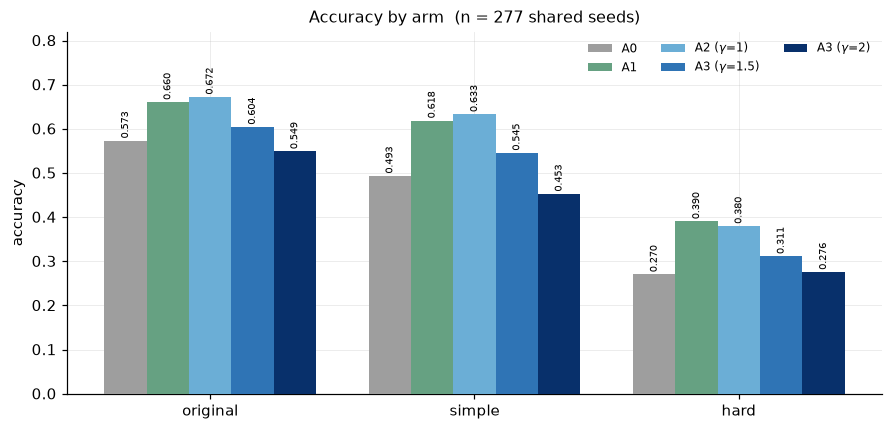

                            A0                    A1                    A2                A3g1.5                    A3
arm                                                                                                                   
original  0.573 [0.531, 0.616]  0.660 [0.613, 0.707]  0.672 [0.626, 0.718]  0.604 [0.560, 0.648]  0.549 [0.507, 0.591]
simple    0.493 [0.450, 0.539]  0.618 [0.571, 0.666]  0.633 [0.585, 0.680]  0.545 [0.501, 0.590]  0.453 [0.410, 0.496]
hard      0.270 [0.231, 0.311]  0.390 [0.345, 0.436]  0.380 [0.335, 0.425]  0.311 [0.271, 0.353]  0.276 [0.237, 0.315]

n = 277 seeds per cell


In [10]:
fig, ax = plt.subplots(figsize=(8.2, 4.0))
x, width = np.arange(len(ARMS)), BW
F1 = {}
for i, run in enumerate(ORDER):
    vals = [cluster_bootstrap(ACC[run][a]) for a in ARMS]
    F1[run] = vals
    off = boff(i)
    m  = np.array([v["mean"] for v in vals]); lo = np.array([v["lo"] for v in vals])
    hi = np.array([v["hi"] for v in vals])
    ax.bar(x + off, m, width, color=COLOR[run], label=SHORT[run], zorder=3)
    for xi, v in zip(x + off, m):
        ax.annotate(f"{v:.3f}", (xi, v), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=6.4, rotation=90)
ax.set_xticks(x); ax.set_xticklabels(["original", "simple", "hard"])
ax.set_ylabel("accuracy"); ax.set_ylim(0, 0.82)
ax.set_title(f"Accuracy by arm  (n = {len(SHARED)} shared seeds)")
ax.legend(ncol=3, loc="upper right", fontsize=7.8)
fig.tight_layout(); savefig(fig, "fig01_accuracy_by_arm"); plt.show()

T = pd.DataFrame({run: [fmt_ci(v) for v in F1[run]] for run in ORDER}, index=ARMS)
T.index.name = "arm"; print(T.to_string())
print(f"\nn = {F1['A0'][0]['n']} seeds per cell")
RESULTS["fig1_accuracy"] = {run: {a: F1[run][i] for i, a in enumerate(ARMS)} for run in ORDER}

---
## Figure 2 — Degradation trajectory

**Shows.** Left, accuracy across original → simple → hard, one line per ablation. Right,
the same normalised to 1.0 at each ablation's own original, which removes the capability
difference and leaves only the *shape* of the decline.

**Conclude.** This is the distinction the benchmark exists to draw. Simple and hard
falling together is **surface sensitivity** — the model is disturbed by the rewrite
itself. Hard falling much further than simple is **technique dependence** — the model
survives a rewrite that preserves its method and collapses when the method no longer
applies. The right panel is where ablations become comparable: a model can be uniformly
better and still have exactly the same brittleness profile.

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig02_degradation_trajectory.{pdf,png}


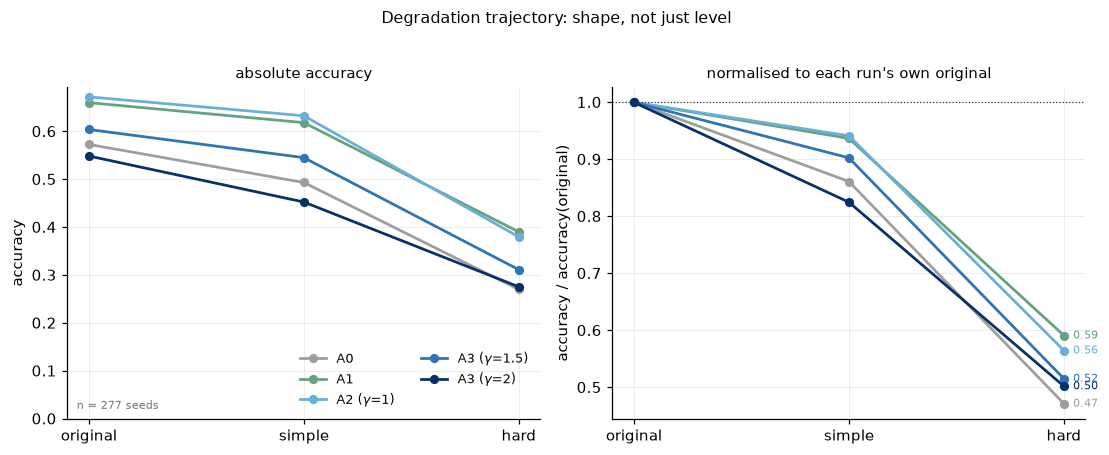

        acc orig  acc simple  acc hard  simple / orig  hard / orig  simple-hard drop
A0        0.5730      0.4935    0.2702         0.8612       0.4714            0.3897
A1        0.6603      0.6185    0.3902         0.9367       0.5910            0.3457
A2        0.6723      0.6328    0.3797         0.9413       0.5648            0.3765
A3g1.5    0.6042      0.5454    0.3113         0.9026       0.5153            0.3874
A3        0.5488      0.4527    0.2756         0.8249       0.5021            0.3228

Retained fraction on 'hard' is the brittleness summary: higher = the structural change costs less. A run that is more capable but has the same 'hard / orig' ratio has not become less technique-dependent, only better.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.0))
x = np.arange(len(ARMS))
NORM = {}
for run in ORDER:
    m = np.array([F1[run][i]["mean"] for i in range(len(ARMS))])
    lo = np.array([F1[run][i]["lo"] for i in range(len(ARMS))])
    hi = np.array([F1[run][i]["hi"] for i in range(len(ARMS))])
    axes[0].plot(x, m, marker="o", ms=5, lw=1.8, color=COLOR[run], label=SHORT[run])
    rel = m / m[0]
    NORM[run] = rel
    axes[1].plot(x, rel, marker="o", ms=5, lw=1.8, color=COLOR[run], label=SHORT[run])
    axes[1].annotate(f"{rel[2]:.2f}", (x[2], rel[2]), xytext=(6, 0),
                     textcoords="offset points", fontsize=7.5, color=COLOR[run], va="center")

for ax, ttl, yl in [(axes[0], "absolute accuracy", "accuracy"),
                    (axes[1], "normalised to each run's own original", "accuracy / accuracy(original)")]:
    ax.set_xticks(x); ax.set_xticklabels(["original", "simple", "hard"])
    ax.set_title(ttl, fontsize=9.5); ax.set_ylabel(yl)
axes[1].axhline(1.0, color="#333", lw=0.8, ls=":")
axes[0].legend(ncol=2); axes[0].set_ylim(bottom=0)
axes[0].text(0.02, 0.03, f"n = {len(SHARED)} seeds", transform=axes[0].transAxes,
             fontsize=7, color="#777")
fig.suptitle("Degradation trajectory: shape, not just level", y=1.02, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig02_degradation_trajectory"); plt.show()

D2 = pd.DataFrame({run: {"acc orig": F1[run][0]["mean"], "acc simple": F1[run][1]["mean"],
                         "acc hard": F1[run][2]["mean"],
                         "simple / orig": NORM[run][1], "hard / orig": NORM[run][2],
                         "simple-hard drop": NORM[run][1] - NORM[run][2]}
                  for run in ORDER}).T
print(D2.round(4).to_string())
print("\nRetained fraction on 'hard' is the brittleness summary: higher = the structural "
      "change costs less. A run that is more capable but has the same 'hard / orig' ratio "
      "has not become less technique-dependent, only better.")
RESULTS["fig2_trajectory"] = D2.to_dict("index")

---
## Figure 3 — Capability versus invariance

**Shows.** x = accuracy on originals, y = invariance gap $\Delta$, one point per
ablation, with arrows tracing the γ path A2 (γ=1) → γ=1.5 → A3 (γ=2). Intervals are
printed beneath the figure.

**Conclude.** The trade-off in one panel, and likely the single most informative figure
in the chapter. **A3 down-and-left of A2 — worse accuracy, no better gap — is levelling
down made visible without argument.** Up-and-left would be a genuine trade; the position
relative to A0 is what says whether training bought anything at all.

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig03_capability_vs_invariance.{pdf,png}


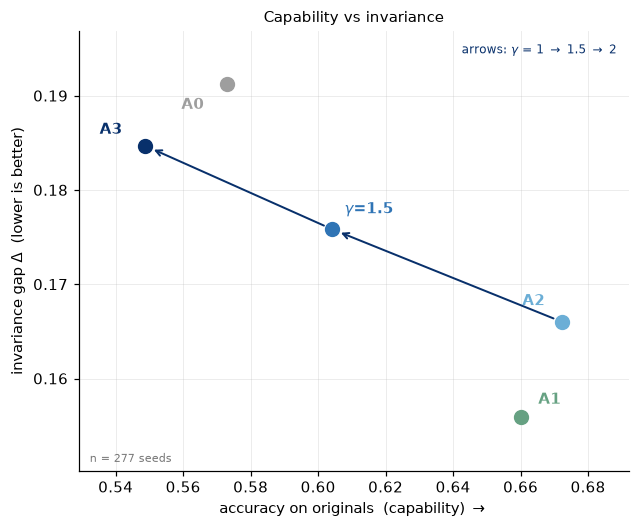

point estimates with 95% cluster-bootstrap intervals:
  A0      acc(orig) 0.573 [0.531, 0.616]   gap 0.191 [0.155, 0.227]
  A1      acc(orig) 0.660 [0.613, 0.707]   gap 0.156 [0.122, 0.191]
  A2      acc(orig) 0.672 [0.626, 0.718]   gap 0.166 [0.130, 0.202]
  A3g1.5  acc(orig) 0.604 [0.560, 0.648]   gap 0.176 [0.138, 0.213]
  A3      acc(orig) 0.549 [0.507, 0.591]   gap 0.185 [0.148, 0.222]

A3 - A2:  acc(orig) -0.1234   gap +0.0187
A3 relative to A2: LEFT (less capable) and ABOVE (larger gap)
A3 relative to A0: acc -0.0242, gap -0.0065


In [12]:
fig, ax = plt.subplots(figsize=(5.9, 4.9))
LBL_OFF = {"A0": (-30, -16), "A1": (11, 9), "A2": (-26, 11), "A3g1.5": (8, 10), "A3": (-30, 8)}
LBL_TXT = {"A3g1.5": "$\\gamma$=1.5", "A3": "A3"}
pts = {}
for run in ORDER:
    a = cluster_bootstrap(ACC[run]["original"]); g = cluster_bootstrap(GAP_ALL[run])
    pts[run] = (a, g)
    ax.plot(a["mean"], g["mean"], "o", ms=9, color=COLOR[run], zorder=3)
    ax.annotate(LBL_TXT.get(run, run), (a["mean"], g["mean"]), xytext=LBL_OFF[run],
                textcoords="offset points", fontsize=10, weight="bold", color=COLOR[run])

path_runs = list(GAMMA_PATH.values())
for r0, r1 in zip(path_runs[:-1], path_runs[1:]):
    ax.annotate("", xy=(pts[r1][0]["mean"], pts[r1][1]["mean"]),
                xytext=(pts[r0][0]["mean"], pts[r0][1]["mean"]),
                arrowprops=dict(arrowstyle="->", color="#08306B", lw=1.3,
                                shrinkA=6, shrinkB=6), zorder=2)
a2, a3 = pts["A2"][0]["mean"], pts["A3"][0]["mean"]
g2, g3 = pts["A2"][1]["mean"], pts["A3"][1]["mean"]
ax.text(0.98, 0.97, "arrows: $\\gamma$ = 1 $\\rightarrow$ 1.5 $\\rightarrow$ 2",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color="#08306B")
ax.set_xlabel("accuracy on originals  (capability) $\\rightarrow$")
ax.set_ylabel("invariance gap $\\Delta$  (lower is better)")
ax.set_title("Capability vs invariance", fontsize=10)
ax.text(0.02, 0.02, f"n = {pts['A0'][0]['n']} seeds", transform=ax.transAxes, fontsize=7, color="#777")
ax.margins(0.16)
fig.tight_layout(); savefig(fig, "fig03_capability_vs_invariance"); plt.show()

d_acc, d_gap = a3 - a2, g3 - g2
print("point estimates with 95% cluster-bootstrap intervals:")
for r in ORDER:
    print(f"  {r:<7} acc(orig) {fmt_ci(pts[r][0])}   gap {fmt_ci(pts[r][1])}")
print()
print(f"A3 - A2:  acc(orig) {d_acc:+.4f}   gap {d_gap:+.4f}")
print("A3 relative to A2: " + ("LEFT (less capable)" if d_acc < 0 else "RIGHT (more capable)")
      + " and " + ("BELOW (smaller gap)" if d_gap < 0 else "ABOVE (larger gap)"))
print(f"A3 relative to A0: acc {pts['A3'][0]['mean'] - pts['A0'][0]['mean']:+.4f}, "
      f"gap {pts['A3'][1]['mean'] - pts['A0'][1]['mean']:+.4f}")
RESULTS["fig3_points"] = {r: {"acc_orig": pts[r][0], "gap": pts[r][1]} for r in ORDER}

---
## Figure 4 — Within-seed variance beside accuracy

**Shows.** Two panels on a shared ablation axis: within-seed variance of arm accuracy,
and mean accuracy across the two perturbed arms. The dashed line marks the A0 level;
intervals are printed beneath the figure.

**Conclude.** The essential pairing, and the trap the brief names explicitly. A variance
penalty is *supposed* to lower the left panel. It only counts as success if the right
panel holds. **A3's variance is lower than A2's and simultaneously matches A0's, while
A3's accuracies also match A0's — variance fell by lowering everything, not by
equalising anything.** Neither panel alone distinguishes equalising upward from
equalising downward.

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig04_variance_vs_accuracy.{pdf,png}


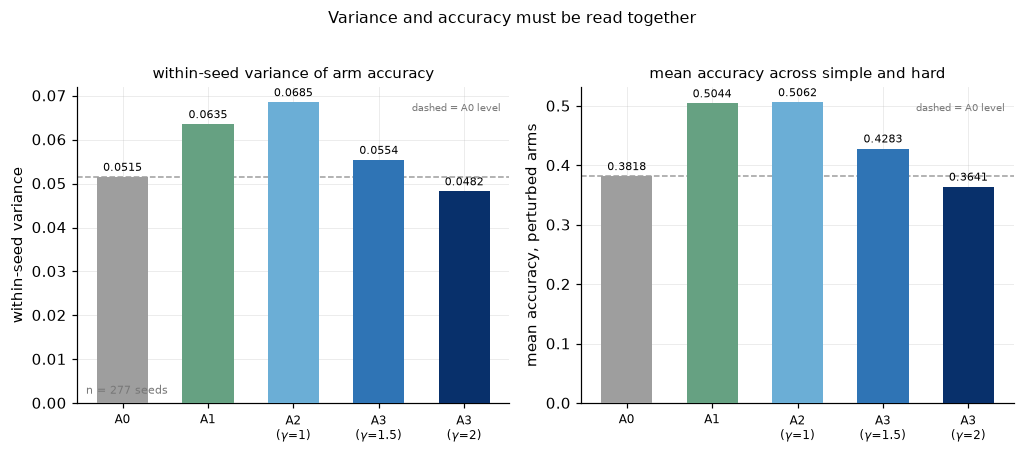

run   within-seed variance          mean acc (perturbed arms)
A0    0.0515 [0.0431, 0.0604]       0.3818 [0.3473, 0.4178]
A1    0.0635 [0.0540, 0.0736]       0.5044 [0.4666, 0.5420]
A2    0.0685 [0.0583, 0.0790]       0.5062 [0.4681, 0.5450]
A3g1.5    0.0554 [0.0469, 0.0639]       0.4283 [0.3936, 0.4641]
A3    0.0482 [0.0408, 0.0560]       0.3641 [0.3299, 0.3987]

A3 vs A2: variance -0.0203, accuracy -0.1421
A3 vs A0: variance -0.0033, accuracy -0.0177


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.0))
x = np.arange(len(ORDER))
wv = {r: cluster_bootstrap(WVAR[r]) for r in ORDER}
av = {r: cluster_bootstrap(ACC_PERT[r]) for r in ORDER}

for ax, vals, ylab, title in [
        (axes[0], wv, "within-seed variance", "within-seed variance of arm accuracy"),
        (axes[1], av, "mean accuracy, perturbed arms", "mean accuracy across simple and hard")]:
    m  = np.array([vals[r]["mean"] for r in ORDER]); lo = np.array([vals[r]["lo"] for r in ORDER])
    hi = np.array([vals[r]["hi"] for r in ORDER])
    ax.bar(x, m, 0.6, color=[COLOR[r] for r in ORDER], zorder=3)
    ax.axhline(vals["A0"]["mean"], color="#9E9E9E", ls="--", lw=1.0, zorder=2)
    for xi, v in zip(x, m):
        ax.annotate(f"{v:.4f}", (xi, v), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels([SHORT[r].replace(" (", "\n(") for r in ORDER], fontsize=8)
    ax.set_ylabel(ylab); ax.set_title(title, fontsize=9.5)
    ax.text(0.98, 0.95, "dashed = A0 level", transform=ax.transAxes, ha="right",
            va="top", fontsize=6.8, color="#777")
axes[0].text(0.02, 0.03, f"n = {wv['A0']['n']} seeds", transform=axes[0].transAxes,
             fontsize=7, color="#777")
fig.suptitle("Variance and accuracy must be read together", y=1.02, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig04_variance_vs_accuracy"); plt.show()

print("run   within-seed variance          mean acc (perturbed arms)")
for r in ORDER:
    print(f"{r}    {fmt_ci(wv[r], 4):<28}  {fmt_ci(av[r], 4)}")
print(f"\nA3 vs A2: variance {wv['A3']['mean'] - wv['A2']['mean']:+.4f}, "
      f"accuracy {av['A3']['mean'] - av['A2']['mean']:+.4f}")
print(f"A3 vs A0: variance {wv['A3']['mean'] - wv['A0']['mean']:+.4f}, "
      f"accuracy {av['A3']['mean'] - av['A0']['mean']:+.4f}")
RESULTS["fig4"] = {"within_var": wv, "acc_perturbed": av}

---
## Figure 5 — RSR and recovery

**Shows.** $\mathrm{RSR} = \Pr[\text{arm correct} \mid \text{original correct}]$ for
simple and hard per ablation (solid), with the recovery rate
$\Pr[\text{arm correct} \mid \text{original incorrect}]$ as a lighter secondary bar.
Ratio-of-sums cluster-bootstrap intervals are printed beneath the figure.

**Conclude.** RSR conditions capability away, so it is the fair comparison across models
of different strength — unlike $\Delta$, it cannot be improved by getting worse at the
originals.

**On recovery.** The brief asks for recovery to be flagged if it is not near zero. On
this benchmark it is **not** near zero, and that is structural rather than a data fault:
the hard perturbation is a *different problem with a different answer*, so a model can
fail the original and still solve the rewrite. Recovery is therefore a genuine quantity
here, not a red flag — but it does mean RSR alone understates what these models can do,
and the raw accuracies in Figure 1 have to be read beside it.

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig05_rsr_recovery.{pdf,png}


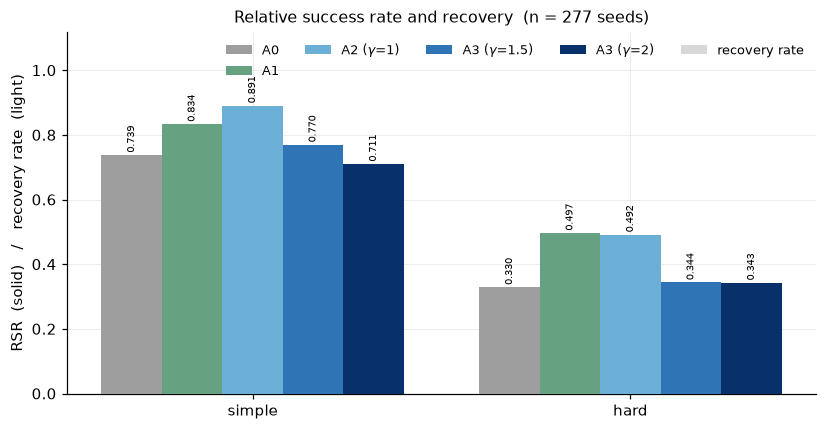

           RSR [95% CI]                    recovery [95% CI]
  A0 simple  0.739 [0.672, 0.801]           0.218 [0.140, 0.304]
  A0 hard    0.330 [0.260, 0.400]           0.129 [0.066, 0.198]
  A1 simple  0.834 [0.780, 0.884]           0.202 [0.122, 0.289]
  A1 hard    0.497 [0.427, 0.570]           0.214 [0.131, 0.304]
  A2 simple  0.891 [0.845, 0.933]           0.179 [0.100, 0.265]
  A2 hard    0.492 [0.422, 0.562]           0.202 [0.122, 0.292]
  A3g1.5 simple  0.770 [0.707, 0.830]           0.255 [0.169, 0.345]
  A3g1.5 hard    0.344 [0.275, 0.415]           0.223 [0.143, 0.312]
  A3 simple  0.711 [0.642, 0.779]           0.198 [0.126, 0.275]
  A3 hard    0.343 [0.273, 0.419]           0.153 [0.090, 0.222]

recovery exceeds 0.05 in 10/10 cells (max 0.255). FLAGGED: on MATH-Perturb the perturbed arms have different correct answers, so solving a rewrite after failing the original is expected behaviour, not a dataset fault.


In [14]:
fig, ax = plt.subplots(figsize=(7.6, 4.0))
x, width = np.arange(len(PERT)), BW
RSR, REC = {}, {}
for i, run in enumerate(ORDER):
    rs = [ratio_cluster_bootstrap(*rsr_parts(run, a)[0]) for a in PERT]
    rc = [ratio_cluster_bootstrap(*rsr_parts(run, a)[1]) for a in PERT]
    RSR[run], REC[run] = rs, rc
    off = boff(i)
    m  = np.array([v["mean"] for v in rs]); lo = np.array([v["lo"] for v in rs])
    hi = np.array([v["hi"] for v in rs])
    ax.bar(x + off, m, width, color=COLOR[run], label=SHORT[run], zorder=3)
    ax.bar(x + off, [v["mean"] for v in rc], width * 0.55, color=COLOR[run],
           alpha=0.32, zorder=4, edgecolor="none")
    for xi, v in zip(x + off, m):
        ax.annotate(f"{v:.3f}", (xi, v), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=6.3, rotation=90)
ax.set_xticks(x); ax.set_xticklabels(["simple", "hard"])
ax.set_ylabel("RSR  (solid)   /   recovery rate  (light)")
ax.set_title(f"Relative success rate and recovery  (n = {len(SHARED)} seeds)")
h, l = ax.get_legend_handles_labels()
h.append(Patch(facecolor="#888", alpha=0.32)); l.append("recovery rate")
ax.legend(h, l, ncol=5, loc="upper right"); ax.set_ylim(0, 1.12)
fig.tight_layout(); savefig(fig, "fig05_rsr_recovery"); plt.show()

print("           RSR [95% CI]                    recovery [95% CI]")
flags = []
for run in ORDER:
    for j, arm in enumerate(PERT):
        rc = REC[run][j]
        if rc["mean"] > 0.05:
            flags.append((run, arm, rc["mean"]))
        print(f"  {run} {arm:<7} {fmt_ci(RSR[run][j]):<30} {fmt_ci(rc)}")
print(f"\nrecovery exceeds 0.05 in {len(flags)}/{len(ORDER)*len(PERT)} cells "
      f"(max {max(f[2] for f in flags):.3f}). FLAGGED: on MATH-Perturb the perturbed arms "
      "have different correct answers, so solving a rewrite after failing the original is "
      "expected behaviour, not a dataset fault.")
RESULTS["fig5_rsr"] = {r: {a: RSR[r][j] for j, a in enumerate(PERT)} for r in ORDER}
RESULTS["fig5_recovery"] = {r: {a: REC[r][j] for j, a in enumerate(PERT)} for r in ORDER}
RESULTS["fig5_recovery_flags"] = [{"run": r, "arm": a, "recovery": float(v)} for r, a, v in flags]

---
## Figure 6 — Outcome taxonomy: the memorisation figure

**Shows.** Every seed classified by the triple $(e_i, h_{\text{simple}}, h_{\text{hard}})$
from `groups.jsonl`:

| pattern | label |
|---|---|
| 1,1,1 | robust — solved throughout |
| **1,1,0** | **technique memorisation** — solved original and simple, failed hard |
| 1,0,0 | brittle — solved original only |
| 1,0,1 | inconsistent |
| 0,\*,\* | not solved originally (one bucket) |

**Conclude.** This is the benchmark's own memorisation signature made explicit: the
shortcut that survives a perturbation preserving the technique and fails when the
technique no longer applies. **The headline number is the `1,1,0` count as a fraction of
seeds solved originally** — that conditional is what makes it comparable across models of
different capability. Whether RL training reduces it is a direct test of whether the
model learned reasoning or technique.

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig06_outcome_taxonomy.{pdf,png}


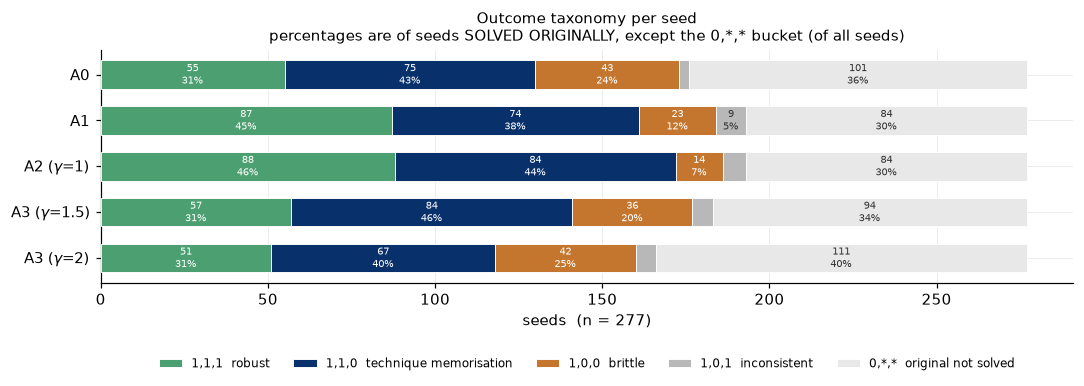

        1,1,1  robust  1,1,0  technique memorisation  1,0,0  brittle  1,0,1  inconsistent  0,*,*  original not solved  seeds solved originally  1,1,0 as % of solved
A0                 55                             75              43                    3                         101                      176             42.613636
A1                 87                             74              23                    9                          84                      193             38.341969
A2                 88                             84              14                    7                          84                      193             43.523316
A3g1.5             57                             84              36                    6                          94                      183             45.901639
A3                 51                             67              42                    6                         111                      166             40.361446

THE BENCH

In [15]:
PATTERNS = [((1, 1, 1), "1,1,1  robust", "#4C9F70"),
            ((1, 1, 0), "1,1,0  technique memorisation", "#08306B"),
            ((1, 0, 0), "1,0,0  brittle", "#C4762F"),
            ((1, 0, 1), "1,0,1  inconsistent", "#B8B8B8"),
            ((0, None, None), "0,*,*  original not solved", "#E8E8E8")]

def taxonomy(run):
    sub = GR[GR.run == run]
    cnt = Counter()
    for _, r in sub.iterrows():
        e, hs, hh = int(r.e_i), r.h_simple, r.h_hard
        if e == 0:
            cnt[(0, None, None)] += 1
        else:
            cnt[(1, int(hs), int(hh))] += 1
    return cnt

TAX = {r: taxonomy(r) for r in ORDER}
solved = {r: sum(v for k, v in TAX[r].items() if k[0] == 1) for r in ORDER}

fig, ax = plt.subplots(figsize=(10.0, 4.0))
y = np.arange(len(ORDER))[::-1]
left = np.zeros(len(ORDER))
for key, lab, col in PATTERNS:
    vals = np.array([TAX[r].get(key, 0) for r in ORDER], dtype=float)
    ax.barh(y, vals, 0.62, left=left, color=col, label=lab, zorder=3,
            edgecolor="white", linewidth=0.6)
    for yi, (v, l0, r_) in zip(y, zip(vals, left, ORDER)):
        if v >= 8:
            pct = 100 * v / solved[r_] if key[0] == 1 else 100 * v / len(SHARED)
            ax.annotate(f"{int(v)}\n{pct:.0f}%", (l0 + v / 2, yi), ha="center", va="center",
                        fontsize=6.8, color="white" if col in ("#08306B", "#4C9F70", "#C4762F") else "#333")
    left += vals
ax.set_yticks(y); ax.set_yticklabels([SHORT[r] for r in ORDER])
ax.set_xlabel(f"seeds  (n = {len(SHARED)})")
ax.set_title("Outcome taxonomy per seed\n"
             "percentages are of seeds SOLVED ORIGINALLY, except the 0,*,* bucket (of all seeds)",
             fontsize=9.5)
ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.42), fontsize=7.6)
fig.tight_layout(); savefig(fig, "fig06_outcome_taxonomy"); plt.show()

T6 = pd.DataFrame({r: {lab: TAX[r].get(key, 0) for key, lab, _ in PATTERNS} for r in ORDER}).T
T6["seeds solved originally"] = [solved[r] for r in ORDER]
T6["1,1,0 as % of solved"] = [100 * TAX[r].get((1, 1, 0), 0) / solved[r] for r in ORDER]
print(T6.to_string())
print("\nTHE BENCHMARK'S HEADLINE NUMBER -- technique memorisation as a fraction of seeds "
      "solved originally:")
for r in ORDER:
    print(f"  {r}: {TAX[r].get((1,1,0),0):>3} / {solved[r]:>3} = {100*TAX[r].get((1,1,0),0)/solved[r]:.1f}%")
RESULTS["fig6_taxonomy"] = {r: {str(k): TAX[r].get(k, 0) for k, _, _ in PATTERNS} for r in ORDER}
RESULTS["fig6_memorisation_frac"] = {r: TAX[r].get((1, 1, 0), 0) / solved[r] for r in ORDER}
RESULTS["fig6_solved_originally"] = solved

In [16]:
# Is the change in the memorisation bucket real? Paired bootstrap on the per-seed
# indicator, conditioned on the original being solved in BOTH runs being compared.
def bucket_indicator(run, pattern):
    '''Per-seed 0/1 for one taxonomy bucket, restricted to seeds solved originally.'''
    sub = GR[GR.run == run]
    return {r.group_id: float((int(r.h_simple), int(r.h_hard)) == pattern)
            for _, r in sub.iterrows() if r.e_i == 1}

def mem_indicator(run): return bucket_indicator(run, (1, 0))

BUCKETS = {"1,1,0 technique memorisation": (1, 0),
           "1,1,1 robust": (1, 1),
           "1,0,0 brittle": (0, 0)}
PAIRS = [("A1", "A0"), ("A2", "A1"), ("A3g1.5", "A2"), ("A3", "A2"),
         ("A3", "A3g1.5"), ("A3g1.5", "A0"), ("A3", "A0")]

print("paired contrasts on taxonomy composition, conditioned on the original being solved "
      "in BOTH runs")
TAXC = {}
for name, pat in BUCKETS.items():
    print(f"\n  {name}")
    for a, b in PAIRS:
        d = paired_cluster_bootstrap(bucket_indicator(a, pat), bucket_indicator(b, pat))
        TAXC[f"{name}|{a} - {b}"] = d
        print(f"    {a} - {b}: {fmt_ci(d)}{star(d)}   (n = {d['n']})")
print("\n*  interval excludes zero")
MEMC = {f"{a} - {b}": TAXC[f"1,1,0 technique memorisation|{a} - {b}"] for a, b in PAIRS}
RESULTS["fig6_contrasts"] = MEMC
RESULTS["fig6_bucket_contrasts"] = TAXC

paired contrasts on taxonomy composition, conditioned on the original being solved in BOTH runs

  1,1,0 technique memorisation
    A1 - A0: -0.056 [-0.131, 0.019]   (n = 160)
    A2 - A1: 0.028 [-0.033, 0.088]   (n = 181)
    A3g1.5 - A2: 0.055 [-0.018, 0.127]   (n = 165)
    A3 - A2: 0.020 [-0.067, 0.100]   (n = 150)


    A3 - A3g1.5: -0.039 [-0.124, 0.046]   (n = 153)
    A3g1.5 - A0: 0.013 [-0.057, 0.082]   (n = 158)
    A3 - A0: -0.020 [-0.093, 0.053]   (n = 151)

  1,1,1 robust
    A1 - A0: 0.150 [0.087, 0.219] *   (n = 160)
    A2 - A1: 0.000 [-0.055, 0.055]   (n = 181)
    A3g1.5 - A2: -0.133 [-0.206, -0.067] *   (n = 165)


    A3 - A2: -0.167 [-0.240, -0.093] *   (n = 150)
    A3 - A3g1.5: -0.020 [-0.078, 0.039]   (n = 153)
    A3g1.5 - A0: 0.013 [-0.038, 0.063]   (n = 158)
    A3 - A0: -0.020 [-0.073, 0.033]   (n = 151)

  1,0,0 brittle
    A1 - A0: -0.113 [-0.175, -0.056] *   (n = 160)
    A2 - A1: -0.022 [-0.061, 0.017]   (n = 181)


    A3g1.5 - A2: 0.091 [0.042, 0.145] *   (n = 165)
    A3 - A2: 0.153 [0.093, 0.213] *   (n = 150)
    A3 - A3g1.5: 0.059 [-0.007, 0.124]   (n = 153)
    A3g1.5 - A0: -0.038 [-0.095, 0.013]   (n = 158)
    A3 - A0: 0.026 [-0.026, 0.079]   (n = 151)

*  interval excludes zero


---
## Figure 7 — Per-seed gap scatter, simple versus hard

**Shows.** One point per seed: x = `gap_by_arm.simple`, y = `gap_by_arm.hard`, with the
$y = x$ diagonal, faceted by ablation. Annotated with the fraction of seeds above the
diagonal and the paired `hard_minus_simple_gap` mean with its 95% interval.

**Conclude.** Figure 2 shows hard is harder *on average*; this tests whether it is
reliably harder **on the same problems**. Mass above the diagonal means the structural
perturbation costs more than the surface one seed by seed, not just in aggregate. The
paired interval is the test — stated plainly below as to whether it excludes zero.

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig07_gap_scatter.{pdf,png}


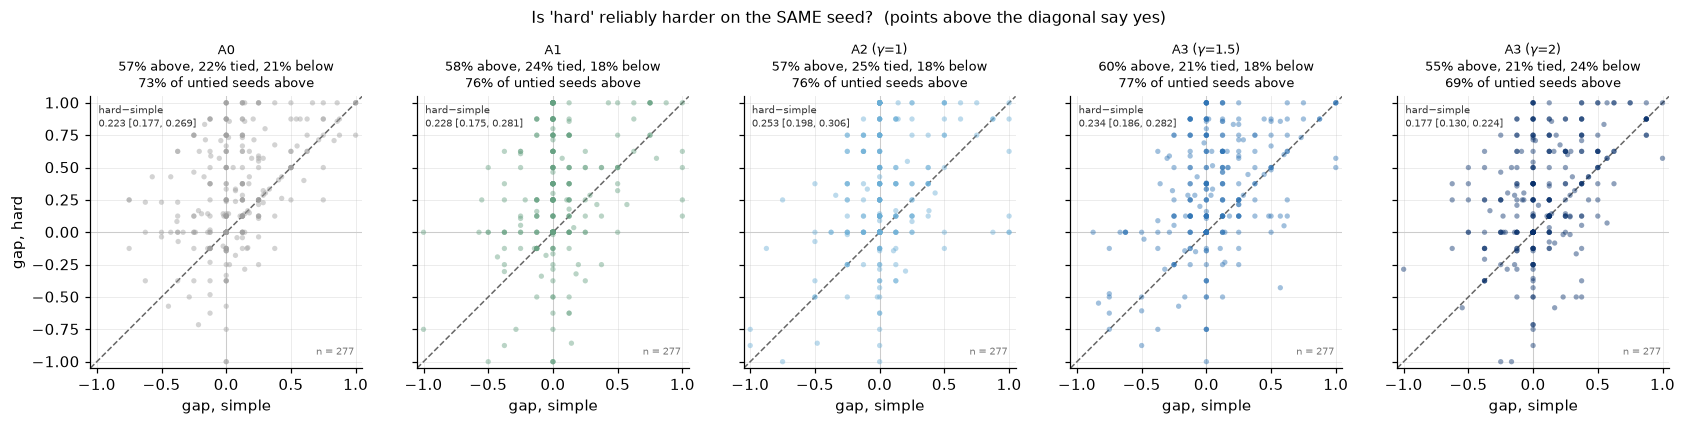

run     above    tied   below  above/untied   hard - simple gap [95% CI]    verdict
A0      0.570   0.224   0.206         0.735   0.223 [0.177, 0.269]          EXCLUDES zero
A1      0.578   0.242   0.181         0.762   0.228 [0.175, 0.281]          EXCLUDES zero
A2      0.570   0.253   0.177         0.763   0.253 [0.198, 0.306]          EXCLUDES zero
A3g1.5   0.603   0.213   0.184         0.766   0.234 [0.186, 0.282]          EXCLUDES zero
A3      0.545   0.213   0.242         0.693   0.177 [0.130, 0.224]          EXCLUDES zero

Ties are seeds where both arms scored identically (frequently both 0 or both 1); they carry no directional information, so the last column -- the share of UNTIED seeds above the diagonal -- is the sharper read.

Shipped summary hard_minus_simple_gap (per run, own seed set):
  A0: 0.2233 [0.1776, 0.2697]  n=277
  A1: 0.2295 [0.1772, 0.2820]  n=278
  A2: 0.2543 [0.2009, 0.3082]  n=278
  A3g1.5: 0.2355 [0.1884, 0.2837]  n=278
  A3: 0.1771 [0.1301, 0.2246]  n=278


In [17]:
fig, axes = plt.subplots(1, len(ORDER), figsize=(3.1 * len(ORDER), 3.4),
                         sharex=True, sharey=True)
HMS = {}
for ax, run in zip(np.atleast_1d(axes), ORDER):
    sub = GR[(GR.run == run)].dropna(subset=["gap_simple", "gap_hard"])
    ax.axhline(0, color="#CCC", lw=0.7); ax.axvline(0, color="#CCC", lw=0.7)
    lim = (-1.05, 1.05)
    ax.plot(lim, lim, ls="--", lw=1.0, color="#666", zorder=2)
    ax.scatter(sub.gap_simple, sub.gap_hard, s=12, alpha=0.45, color=COLOR[run],
               edgecolors="none", zorder=3)
    d = paired_cluster_bootstrap(dict(zip(sub.group_id, sub.gap_hard)),
                                 dict(zip(sub.group_id, sub.gap_simple)))
    above = float((sub.gap_hard > sub.gap_simple).mean())
    equal = float(np.isclose(sub.gap_hard, sub.gap_simple).mean())
    below = float((sub.gap_hard < sub.gap_simple).mean())
    # ties are common (both arms at the same accuracy, often both 0 or both 1), so the
    # share above the diagonal is reported against the share strictly below, not against 100%.
    ratio = above / max(above + below, 1e-12)
    HMS[run] = {"hms": d, "frac_above": above, "frac_equal": equal, "frac_below": below,
                "above_of_untied": ratio, "n": len(sub)}
    ax.set_title(f"{SHORT[run]}\n{100*above:.0f}% above, {100*equal:.0f}% tied, "
                 f"{100*below:.0f}% below\n{100*ratio:.0f}% of untied seeds above",
                 fontsize=8.2)
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
    ax.set_xlabel("gap, simple")
    ax.text(0.03, 0.97, f"hard$-$simple\n{fmt_ci(d)}", transform=ax.transAxes,
            va="top", ha="left", fontsize=6.6, color="#333")
    ax.text(0.97, 0.05, f"n = {len(sub)}", transform=ax.transAxes, ha="right",
            fontsize=6.6, color="#777")
np.atleast_1d(axes)[0].set_ylabel("gap, hard")
fig.suptitle("Is 'hard' reliably harder on the SAME seed?  (points above the "
             "diagonal say yes)", y=1.04, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig07_gap_scatter"); plt.show()

print(f"{'run':<5}{'above':>8}{'tied':>8}{'below':>8}{'above/untied':>14}   "
      f"{'hard - simple gap [95% CI]':<30}verdict")
for run in ORDER:
    h, d = HMS[run], HMS[run]["hms"]
    print(f"{run:<5}{h['frac_above']:>8.3f}{h['frac_equal']:>8.3f}{h['frac_below']:>8.3f}"
          f"{h['above_of_untied']:>14.3f}   {fmt_ci(d):<30}"
          f"{'EXCLUDES zero' if d['significant'] else 'contains zero'}")
print("\nTies are seeds where both arms scored identically (frequently both 0 or both 1); they "
      "carry no directional information, so the last column -- the share of UNTIED seeds above "
      "the diagonal -- is the sharper read.")
print("\nShipped summary hard_minus_simple_gap (per run, own seed set):")
for run in ORDER:
    h = data[run]["summary"]["hard_minus_simple_gap"]
    print(f"  {run}: {h['mean']:.4f} [{h['ci'][0]:.4f}, {h['ci'][1]:.4f}]  n={h['n_groups']}")
RESULTS["fig7_hard_minus_simple"] = {r: {"paired": HMS[r]["hms"],
                                         "frac_above_diagonal": HMS[r]["frac_above"],
                                         "n": HMS[r]["n"]} for r in ORDER}

---
## Figure 8 — $\hat{R}$ by arm and global

**Shows.** `r_hat_simple`, `r_hat_hard` and `r_hat_global` per ablation as horizontal
bars, **each annotated with its own $\beta$**.

**Conclude.** $\hat{R}$ rescales itself to the typical drop it observes
($\beta = \ln 2 / \tilde d$, $\tilde d$ the median positive drop), so two $\hat{R}$
values computed under different $\beta$ are not on the same scale. The annotation is the
point of the figure, not decoration.

Two caveats stated rather than buried. First, $\hat{R}$ is **not comparable across
benchmarks** without $\beta$. Second, MATH-Perturb's simple/hard axis is a
*solution-strategy* split, not the surface/parametric split $\hat{R}_{\text{global}}$
was originally defined over, so `r_hat_global` here is an **analogue** of that quantity
rather than the same statistic.

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig08_rhat.{pdf,png}


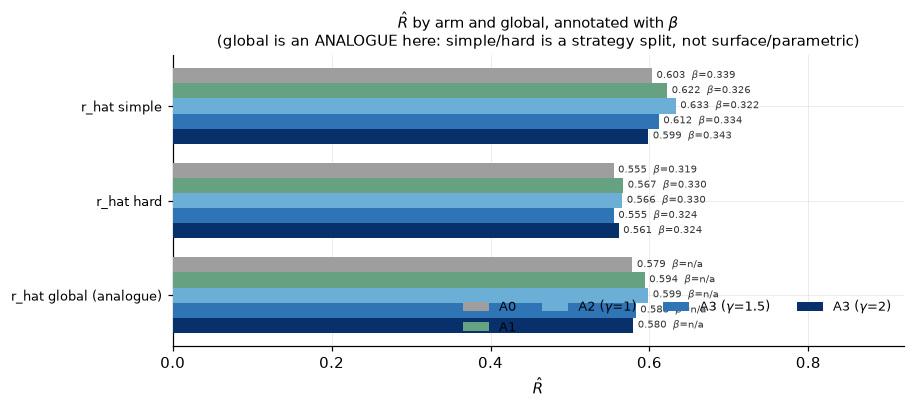

run                          A0      A1      A2      A3  A3g1.5
slice                                                          
r_hat simple             0.6032  0.6223  0.6331  0.5986  0.6118
r_hat hard               0.5548  0.5670  0.5658  0.5613  0.5551
r_hat global (analogue)  0.5785  0.5940  0.5985  0.5796  0.5828

beta by slice (why R-hat needs it reported alongside):
run               A0      A1      A2      A3  A3g1.5
slice                                               
r_hat hard    0.3187  0.3302  0.3297  0.3238  0.3236
r_hat simple  0.3394  0.3256  0.3218  0.3432  0.3343


In [18]:
def rhat_for(run, arm):
    sub = GR[GR.run == run].dropna(subset=[f"h_{arm}"])
    return M.r_hat(sub.e_i.tolist(), sub[f"h_{arm}"].astype(int).tolist())

rows8 = []
for run in ORDER:
    rr = {a: rhat_for(run, a) for a in PERT}
    for a in PERT:
        rows8.append({"run": run, "slice": f"r_hat {a}", "r_hat": rr[a]["r_hat"],
                      "beta": rr[a]["beta"], "N": rr[a]["N"]})
    rows8.append({"run": run, "slice": "r_hat global (analogue)",
                  "r_hat": M.r_hat_global(rr["simple"]["r_hat"], rr["hard"]["r_hat"]),
                  "beta": np.nan, "N": rr["simple"]["N"]})
R8 = pd.DataFrame(rows8)
slices = ["r_hat simple", "r_hat hard", "r_hat global (analogue)"]

fig, ax = plt.subplots(figsize=(8.4, 3.8))
y, h_ = np.arange(len(slices)), BW
for i, run in enumerate(ORDER):
    sub = R8[R8.run == run].set_index("slice").loc[slices]
    off = boff(i)
    ax.barh(y + off, sub.r_hat, h_, color=COLOR[run], label=SHORT[run], zorder=3)
    for yy, (v, b) in zip(y + off, zip(sub.r_hat, sub.beta)):
        ax.annotate(f"{v:.3f}  " + (r"$\beta$=" + f"{b:.3f}" if np.isfinite(b) else r"$\beta$=n/a"),
                    (v, yy), xytext=(3, 0), textcoords="offset points",
                    va="center", fontsize=6.6, color="#333")
ax.set_yticks(y); ax.set_yticklabels(slices, fontsize=8.5); ax.invert_yaxis()
ax.set_xlabel("$\\hat{R}$"); ax.set_xlim(0, 0.92)
ax.set_title("$\\hat{R}$ by arm and global, annotated with $\\beta$\n"
             "(global is an ANALOGUE here: simple/hard is a strategy split, not surface/parametric)",
             fontsize=9.5)
ax.legend(ncol=4, loc="lower right")
fig.tight_layout(); savefig(fig, "fig08_rhat"); plt.show()

print(R8.pivot_table(index="slice", columns="run", values="r_hat").reindex(slices).round(4).to_string())
print("\nbeta by slice (why R-hat needs it reported alongside):")
print(R8[R8.beta.notna()].pivot_table(index="slice", columns="run", values="beta").round(4).to_string())
RESULTS["fig8_rhat"] = R8.to_dict("records")

---
## Figure 9 — G-Pass@8 reliability profile

**Shows.** G-Pass@8 at $\tau \in \{0.5, 0.75, 1.0\}$ for each arm and ablation,
annotated with mG-Pass@8.

**Conclude.** pass@k asks whether the model *can* solve a problem; G-Pass asks whether it
does so *dependably*. $\tau = 0.5$ requires half of eight samples correct, $\tau = 1.0$
requires all eight. The decay across $\tau$ is the reliability profile, and the gap
between avg@n and mG-Pass@n is the **reliability deficit** — capability that does not
survive being asked repeatedly.

All three arms carry 8 attempts per item here, so unlike the ASyMOB runs the profile is
complete rather than originals-only.

n_attempted by arm:
           min  max
arm               
hard        8    8
original    8    8
simple      8    8


saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig09_gpass.{pdf,png}


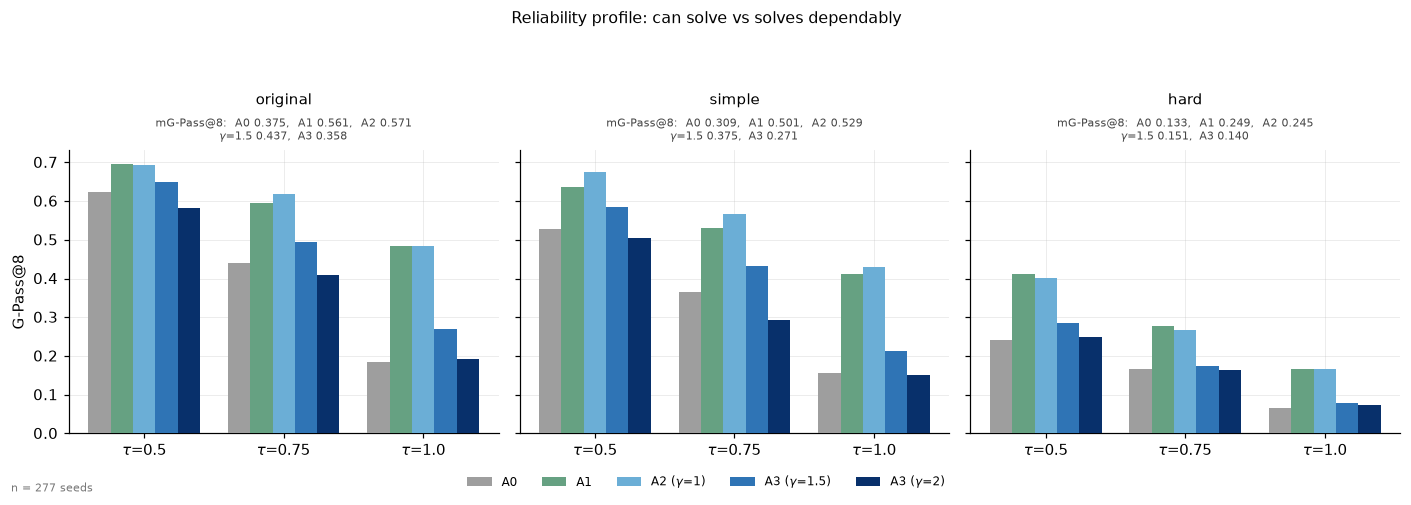

run  arm                      G@8 t=0.5              G@8 t=0.75               G@8 t=1.0   mG-Pass@8     avg@8
A0   original      0.625 [0.567, 0.682]    0.440 [0.383, 0.498]    0.184 [0.141, 0.231]      0.3745    0.5730
A0   simple        0.527 [0.469, 0.585]    0.365 [0.310, 0.422]    0.155 [0.116, 0.199]      0.3087    0.4935


A0   hard          0.242 [0.191, 0.292]    0.166 [0.123, 0.209]    0.065 [0.040, 0.094]      0.1327    0.2702
A1   original      0.697 [0.643, 0.751]    0.596 [0.538, 0.653]    0.484 [0.426, 0.542]      0.5614    0.6603
A1   simple        0.635 [0.578, 0.693]    0.531 [0.473, 0.588]    0.412 [0.354, 0.469]      0.5009    0.6185
A1   hard          0.412 [0.354, 0.469]    0.278 [0.224, 0.332]    0.166 [0.126, 0.213]      0.2491    0.3902
A2   original      0.693 [0.639, 0.747]    0.617 [0.560, 0.675]    0.484 [0.426, 0.542]      0.5713    0.6723
A2   simple        0.675 [0.621, 0.729]    0.567 [0.505, 0.625]    0.430 [0.372, 0.487]      0.5289    0.6328
A2   hard          0.401 [0.343, 0.458]    0.267 [0.217, 0.321]    0.166 [0.123, 0.209]      0.2455    0.3797
A3g1.5original      0.650 [0.592, 0.704]    0.495 [0.437, 0.552]    0.271 [0.220, 0.325]      0.4368    0.6042
A3g1.5simple        0.585 [0.527, 0.643]    0.433 [0.375, 0.491]    0.213 [0.166, 0.260]      0.3755    0.5454
A3g1.5ha

In [19]:
TAUS = [0.5, 0.75, 1.0]
n_att = IT.groupby("arm")["n_attempted"].agg(["min", "max"])
print("n_attempted by arm:\n", n_att.to_string())
assert (n_att["min"] >= 8).all(), "an arm has fewer than 8 attempts -- G-Pass undefined there"

fig, axes = plt.subplots(1, len(ARMS), figsize=(4.3 * len(ARMS), 3.9), sharey=True)
GP = {}
for ax, arm in zip(axes, ARMS):
    x, width = np.arange(len(TAUS)), BW
    for i, run in enumerate(ORDER):
        sub = IT[(IT.run == run) & (IT.arm == arm)]
        vals = [cluster_bootstrap(dict(zip(sub.group_id, sub[f"g_pass_at_8_{t}"]))) for t in TAUS]
        GP[(run, arm)] = vals
        off = boff(i)
        m  = np.array([v["mean"] for v in vals]); lo = np.array([v["lo"] for v in vals])
        hi = np.array([v["hi"] for v in vals])
        ax.bar(x + off, m, width, color=COLOR[run], label=SHORT[run], zorder=3)
    mg = {run: float(IT[(IT.run == run) & (IT.arm == arm)].mg_pass_at_8.mean()) for run in ORDER}
    ax.set_xticks(x); ax.set_xticklabels([f"$\\tau$={t}" for t in TAUS])
    ax.set_title(arm, fontsize=10, pad=30)
    mg_items = [f"{LBL_TXT.get(r, r)} {mg[r]:.3f}" for r in ORDER]
    half = (len(mg_items) + 1) // 2
    ax.text(0.5, 1.02, "mG-Pass@8:  " + ",  ".join(mg_items[:half]) + "\n" + ",  ".join(mg_items[half:]),
            transform=ax.transAxes, ha="center", va="bottom", fontsize=7.2, color="#444")
axes[0].set_ylabel("G-Pass@8")
h9, l9 = axes[0].get_legend_handles_labels()
fig.legend(h9, l9, loc="lower center", ncol=len(ORDER), bbox_to_anchor=(0.5, -0.06), fontsize=8)
fig.text(0.01, -0.04, f"n = {len(SHARED)} seeds", fontsize=7, color="#777")
fig.suptitle("Reliability profile: can solve vs solves dependably", y=1.08, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig09_gpass"); plt.show()

MG = {}
print(f"{'run':<5}{'arm':<10}" + "".join(f"{'G@8 t='+str(t):>24}" for t in TAUS) + f"{'mG-Pass@8':>12}{'avg@8':>10}")
for run in ORDER:
    for arm in ARMS:
        sub = IT[(IT.run == run) & (IT.arm == arm)]
        MG[(run, arm)] = cluster_bootstrap(dict(zip(sub.group_id, sub.mg_pass_at_8)))
        print(f"{run:<5}{arm:<10}" + "".join(f"{fmt_ci(GP[(run,arm)][j]):>24}" for j in range(3))
              + f"{MG[(run,arm)]['mean']:>12.4f}{float(sub.avg_n.mean()):>10.4f}")
print("\nreliability deficit  =  avg@8  -  mG-Pass@8   (capability that does not survive repetition)")
DEF = pd.DataFrame({run: {arm: float(IT[(IT.run == run) & (IT.arm == arm)].avg_n.mean())
                                - MG[(run, arm)]["mean"] for arm in ARMS} for run in ORDER}).T
print(DEF.round(4).to_string())
RESULTS["fig9_gpass"] = {f"{r}|{a}": {f"tau_{t}": GP[(r,a)][j] for j, t in enumerate(TAUS)}
                         for r in ORDER for a in ARMS}
RESULTS["fig9_mgpass8"] = {f"{r}|{a}": MG[(r, a)] for r in ORDER for a in ARMS}
RESULTS["fig9_reliability_deficit"] = DEF.to_dict("index")

---
## Figure 10 — By subject

**Shows.** `gap_simple` and `gap_hard` per subject per ablation, subjects sorted by
`acc_original` descending, with `n_groups` in each label.

**Conclude.** Subject-level variation, and a check that the headline is not carried by
one topic. **Subjects with fewer than 10 seeds are annotated and greyed** — thin cells
are noisy and should not be read as findings. There is no by-level figure: every problem
in this benchmark is MATH Level 5.

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig10_by_subject.{pdf,png}


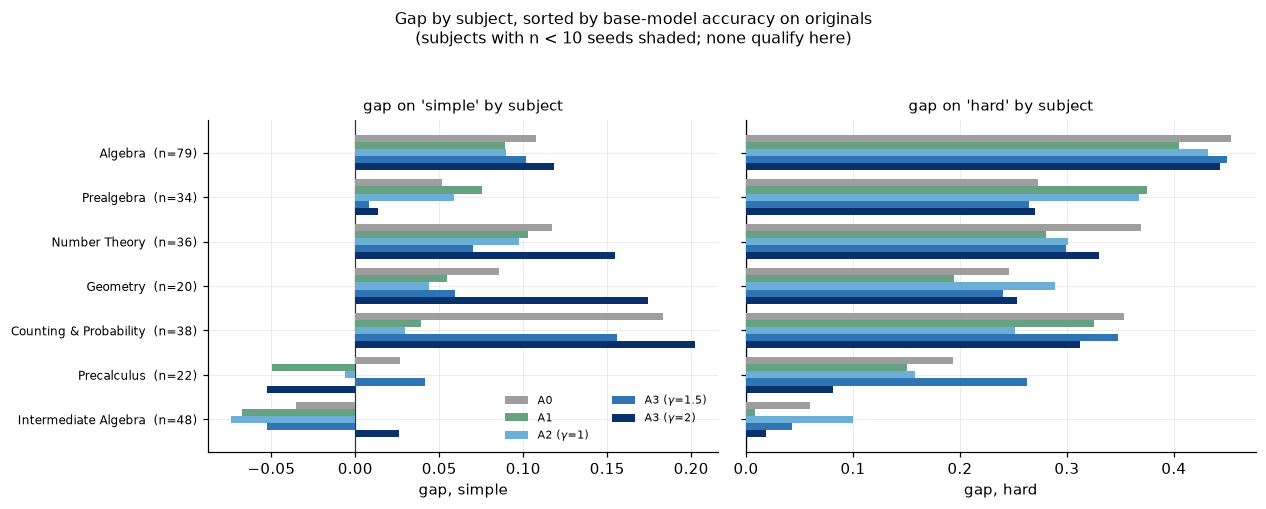

thin subjects (n < 10): none -- every subject has at least 20 seeds
                         n  A0 simple  A0 hard  A1 simple  A1 hard  A2 simple  A2 hard  A3g1.5 simple  A3g1.5 hard  A3 simple  A3 hard
Algebra                 79      0.108    0.454      0.089    0.405      0.090    0.432          0.101        0.450      0.118    0.444
Prealgebra              34      0.052    0.273      0.076    0.375      0.059    0.368          0.008        0.264      0.014    0.270
Number Theory           36      0.117    0.369      0.103    0.280      0.097    0.301          0.070        0.299      0.154    0.330
Geometry                20      0.086    0.246      0.054    0.195      0.044    0.289          0.059        0.240      0.174    0.253
Counting & Probability  38      0.183    0.353      0.039    0.326      0.030    0.251          0.156        0.348      0.202    0.312
Precalculus             22      0.027    0.193     -0.050    0.151     -0.006    0.158          0.041        0.263     -0.

In [20]:
SUBJ_N = GR[GR.run == "A0"].groupby("subject").size().to_dict()
order_subj = (GR[GR.run == "A0"].groupby("subject")["acc_original"].mean()
              .sort_values(ascending=False).index.tolist())
THIN = 10
thin_subj = [s for s in order_subj if SUBJ_N[s] < THIN]

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4), sharey=True)
y, h_ = np.arange(len(order_subj)), BW
SUBJ = {}
for ax, arm in zip(axes, PERT):
    for i, run in enumerate(ORDER):
        vals = []
        for s in order_subj:
            sub = GR[(GR.run == run) & (GR.subject == s)]
            vals.append(cluster_bootstrap(dict(zip(sub.group_id, sub[f"gap_{arm}"]))))
        SUBJ[(run, arm)] = vals
        off = boff(i)
        m  = np.array([v["mean"] for v in vals]); lo = np.array([v["lo"] for v in vals])
        hi = np.array([v["hi"] for v in vals])
        ax.barh(y + off, m, h_, color=COLOR[run], label=SHORT[run], zorder=3,
                )
    ax.axvline(0, color="#333", lw=0.8)
    ax.set_xlabel(f"gap, {arm}"); ax.set_title(f"gap on '{arm}' by subject", fontsize=9.5)
    for yi, s in zip(y, order_subj):
        if s in thin_subj:
            ax.axhspan(yi - 0.5, yi + 0.5, color="#BBB", alpha=0.22, zorder=0)
axes[0].set_yticks(y)
axes[0].set_yticklabels([f"{s}  (n={SUBJ_N[s]})" + ("  [THIN]" if s in thin_subj else "")
                         for s in order_subj], fontsize=8)
axes[0].invert_yaxis(); axes[0].legend(ncol=2, fontsize=7.5, loc="lower right")
fig.suptitle("Gap by subject, sorted by base-model accuracy on originals\n"
             f"(subjects with n < {THIN} seeds shaded; none qualify here)" if not thin_subj else
             f"(subjects with n < {THIN} seeds shaded and marked THIN)",
             y=1.04, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig10_by_subject"); plt.show()

print(f"thin subjects (n < {THIN}): {thin_subj if thin_subj else 'none -- every subject has at least ' + str(min(SUBJ_N.values())) + ' seeds'}")
S10 = pd.DataFrame({f"{run} {arm}": [SUBJ[(run, arm)][i]["mean"] for i in range(len(order_subj))]
                    for run in ORDER for arm in PERT}, index=order_subj)
S10.insert(0, "n", [SUBJ_N[s] for s in order_subj])
print(S10.round(3).to_string())
RESULTS["fig10_by_subject"] = {f"{r}|{a}": {order_subj[i]: SUBJ[(r, a)][i] for i in range(len(order_subj))}
                               for r in ORDER for a in PERT}
RESULTS["subject_n"] = SUBJ_N

---
## Figure 11 — Generation health and the format decomposition

**Left.** `extract_fail_rate`, `truncation_rate` and `mean_n_tokens_completion` per
ablation.

**Right.** For each ablation and arm, the decomposition

```
acc_unconditional = n_correct / n_attempted    # the headline number
acc_given_parsed  = n_correct / n_parseable    # diagnostic
format_rate       = n_parseable / n_attempted
```

**Conclude.** On ASyMOB, A3's extract-failure rate was 12.9× A2's and the failures were
overwhelmingly truncations — the model ran out of tokens before emitting `\boxed{}`.
This figure checks whether MATH-Perturb reproduces that. **If `acc_given_parsed` is
similar for A2 and A3 while `format_rate` differs sharply, the penalty damaged
termination rather than reasoning** — a far more precise finding than "A3 got worse".

**What is deliberately not done.** Seeds on which A3 truncated are *not* filtered out to
re-score the rest. That would be conditioning on the outcome: truncations are not random,
they concentrate on the discriminating items, and method-dependent exclusion manufactures
a favourable result. Truncation without an answer is a genuine task failure and stays in
the headline number. The conditional accuracy is a diagnostic *alongside* it, never a
replacement.

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig11a_generation_health.{pdf,png}


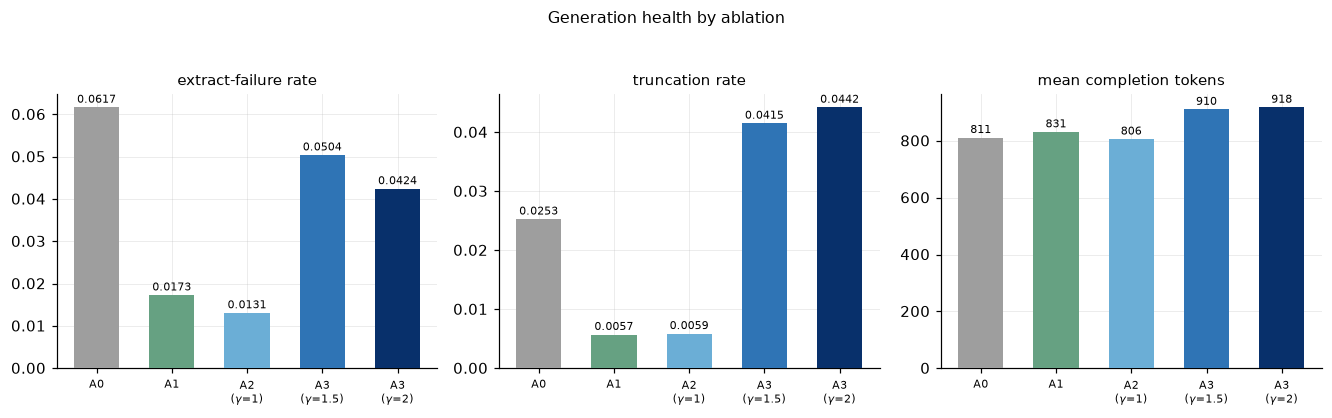

is extract-failure driven by truncation?  correlation and co-occurrence per run
  A0: mean extract_fail=0.0617  mean truncation=0.0253  corr=0.639   >= 39% of extract-fail mass co-occurs with truncation
  A1: mean extract_fail=0.0173  mean truncation=0.0057  corr=0.546   >= 33% of extract-fail mass co-occurs with truncation
  A2: mean extract_fail=0.0131  mean truncation=0.0059  corr=0.707   >= 45% of extract-fail mass co-occurs with truncation
  A3g1.5: mean extract_fail=0.0504  mean truncation=0.0415  corr=0.907   >= 79% of extract-fail mass co-occurs with truncation
  A3: mean extract_fail=0.0424  mean truncation=0.0442  corr=0.971   >= 97% of extract-fail mass co-occurs with truncation


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.6))
for ax, (col, lab) in zip(axes, [("extract_fail_rate", "extract-failure rate"),
                                 ("truncation_rate", "truncation rate"),
                                 ("mean_n_tokens_completion", "mean completion tokens")]):
    x = np.arange(len(ORDER))
    vals = [float(IT[IT.run == r][col].mean()) for r in ORDER]
    ax.bar(x, vals, 0.6, color=[COLOR[r] for r in ORDER], zorder=3)
    for xi, v in zip(x, vals):
        ax.annotate(f"{v:.4f}" if v < 100 else f"{v:.0f}", (xi, v), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=7.5)
    ax.set_xticks(x); ax.set_xticklabels([SHORT[r].replace(" (", "\n(") for r in ORDER], fontsize=7.5)
    ax.set_title(lab, fontsize=9.5)
fig.suptitle("Generation health by ablation", y=1.04, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig11a_generation_health"); plt.show()

# how much of extract-failure is truncation? (the ASyMOB mechanism)
print("is extract-failure driven by truncation?  correlation and co-occurrence per run")
for r in ORDER:
    sub = IT[IT.run == r]
    ef, tr = sub.extract_fail_rate, sub.truncation_rate
    both = float(np.minimum(ef, tr).sum() / max(ef.sum(), 1e-12))
    print(f"  {r}: mean extract_fail={ef.mean():.4f}  mean truncation={tr.mean():.4f}  "
          f"corr={ef.corr(tr):.3f}   >= {100*both:.0f}% of extract-fail mass co-occurs with truncation")

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig11b_format_decomposition.{pdf,png}


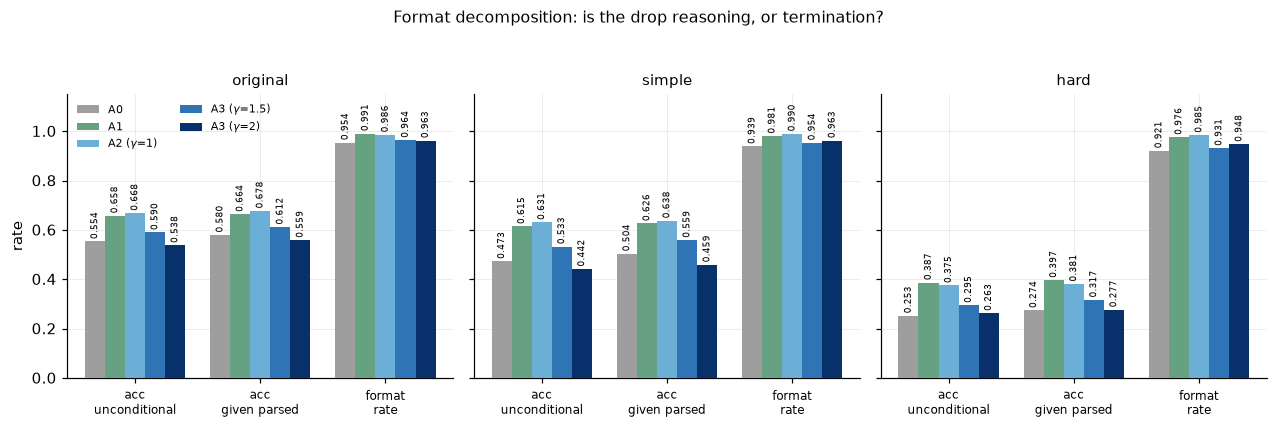

                 acc_unconditional  acc_given_parsed  format_rate
A0|original                 0.5537            0.5801       0.9544
A0|simple                   0.4734            0.5041       0.9391
A0|hard                     0.2527            0.2742       0.9215
A1|original                 0.6579            0.6639       0.9910
A1|simple                   0.6146            0.6265       0.9810
A1|hard                     0.3872            0.3967       0.9761
A2|original                 0.6683            0.6778       0.9860
A2|simple                   0.6313            0.6376       0.9901
A2|hard                     0.3755            0.3813       0.9847
A3g1.5|original             0.5903            0.6124       0.9639
A3g1.5|simple               0.5329            0.5589       0.9535
A3g1.5|hard                 0.2951            0.3169       0.9314
A3|original                 0.5379            0.5588       0.9625
A3|simple                   0.4422            0.4594       0.9625
A3|hard   

In [22]:
DEC = {}
fig, axes = plt.subplots(1, len(ARMS), figsize=(3.9 * len(ARMS), 3.7), sharey=True)
for ax, arm in zip(axes, ARMS):
    x, width = np.arange(3), BW
    for i, run in enumerate(ORDER):
        sub = IT[(IT.run == run) & (IT.arm == arm)]
        nc, na, npar = sub.n_correct.sum(), sub.n_attempted.sum(), sub.n_total.sum()
        vals = [nc / na, (nc / npar if npar else np.nan), npar / na]
        DEC[(run, arm)] = dict(zip(["acc_unconditional", "acc_given_parsed", "format_rate"], vals))
        ax.bar(x + boff(i), vals, width, color=COLOR[run], label=SHORT[run], zorder=3)
        for xi, v in zip(x + boff(i), vals):
            ax.annotate(f"{v:.3f}", (xi, v), xytext=(0, 3), textcoords="offset points",
                        ha="center", fontsize=6.0, rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels(["acc\nunconditional", "acc\ngiven parsed", "format\nrate"], fontsize=7.6)
    ax.set_title(arm, fontsize=9.5)
axes[0].set_ylabel("rate"); axes[0].legend(ncol=2, fontsize=7.2); axes[0].set_ylim(0, 1.15)
fig.suptitle("Format decomposition: is the drop reasoning, or termination?",
             y=1.04, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig11b_format_decomposition"); plt.show()

D11 = pd.DataFrame({f"{r}|{a}": DEC[(r, a)] for r in ORDER for a in ARMS}).T
print(D11.round(4).to_string())
for run in [r for r in GAMMA_PATH.values() if r != "A2"]:
    print(f"\n{run} vs A2, per arm -- does the conditional accuracy hold while the format rate falls?")
    for arm in ARMS:
        d_cond = DEC[(run, arm)]["acc_given_parsed"] - DEC[("A2", arm)]["acc_given_parsed"]
        d_fmt  = DEC[(run, arm)]["format_rate"] - DEC[("A2", arm)]["format_rate"]
        d_unc  = DEC[(run, arm)]["acc_unconditional"] - DEC[("A2", arm)]["acc_unconditional"]
        print(f"  {arm:<9} d acc_unconditional {d_unc:+.4f}   d acc_given_parsed {d_cond:+.4f}   "
              f"d format_rate {d_fmt:+.4f}")
print("\nIf d acc_given_parsed is near zero while d format_rate is strongly negative, the "
      "penalty damaged termination rather than reasoning. If BOTH fall, reasoning degraded too.")
RESULTS["fig11_decomposition"] = {f"{r}|{a}": DEC[(r, a)] for r in ORDER for a in ARMS}
RESULTS["fig11_health"] = {r: {c: float(IT[IT.run == r][c].mean())
                               for c in ["extract_fail_rate", "truncation_rate",
                                         "format_ok_rate", "mean_n_tokens_completion"]}
                           for r in ORDER}

---
## Figure 12 — Confidence by arm and correctness

**Shows.** Mean token-level confidence $\exp(\frac{1}{n}\sum \log p)$ split by arm and by
whether the item was solved. Built only if `mean_confidence` is populated — checked
first, and stated in the notebook if unavailable.

**Conclude.** A calibrated model is more confident when it is right. Equal confidence on
items it fails means the model is not tracking its own competence, and the separation
between the two bars is a crude calibration read.

mean_confidence populated: True (4155/4155 items non-NaN)


saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig12_confidence.{pdf,png}


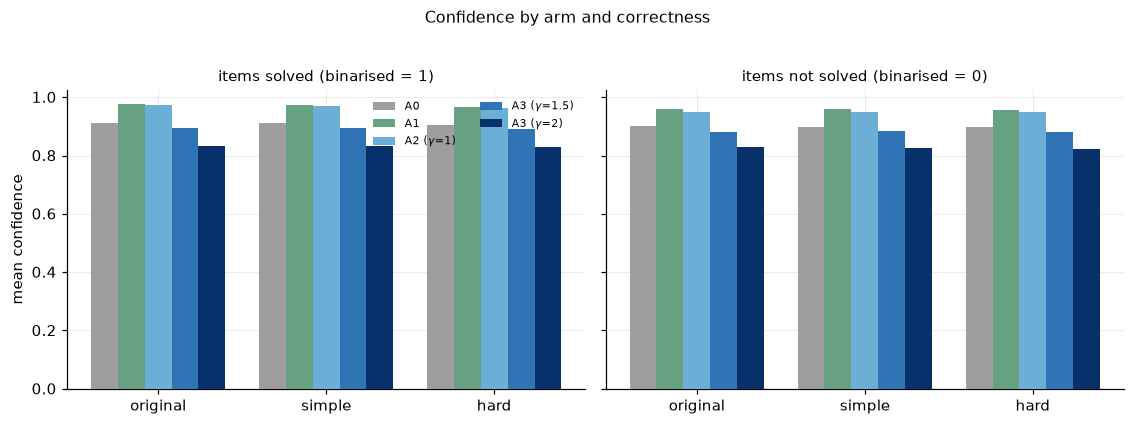

        solved  unsolved  separation
A0      0.9097    0.8988      0.0109
A1      0.9723    0.9577      0.0146
A2      0.9704    0.9501      0.0203
A3g1.5  0.8948    0.8818      0.0130
A3      0.8319    0.8252      0.0067


In [23]:
conf_ok = bool(IT.mean_confidence.notna().any())
print(f"mean_confidence populated: {conf_ok} "
      f"({int(IT.mean_confidence.notna().sum())}/{len(IT)} items non-NaN)")

if not conf_ok:
    print("mean_confidence is entirely NaN in these runs -- Figure 12 is not available and is "
          "omitted rather than approximated.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.7), sharey=True)
    x, width = np.arange(len(ARMS)), BW
    for ax, is_solved, title in [(axes[0], 1, "items solved (binarised = 1)"),
                                 (axes[1], 0, "items not solved (binarised = 0)")]:
        for i, run in enumerate(ORDER):
            v = []
            for arm in ARMS:
                s = IT[(IT.run == run) & (IT.arm == arm) & (IT.binarised == is_solved)]
                v.append(float(s.mean_confidence.mean()) if len(s) else np.nan)
            ax.bar(x + boff(i), v, width, color=COLOR[run], label=SHORT[run], zorder=3)
        ax.set_xticks(x); ax.set_xticklabels(ARMS); ax.set_title(title, fontsize=9.5)
    axes[0].set_ylabel("mean confidence"); axes[0].legend(ncol=2, fontsize=7.5)
    fig.suptitle("Confidence by arm and correctness", y=1.03, fontsize=10.5)
    fig.tight_layout(); savefig(fig, "fig12_confidence"); plt.show()

    CONF = pd.DataFrame({r: {"solved": IT[(IT.run == r) & (IT.binarised == 1)].mean_confidence.mean(),
                             "unsolved": IT[(IT.run == r) & (IT.binarised == 0)].mean_confidence.mean()}
                         for r in ORDER}).T
    CONF["separation"] = CONF.solved - CONF.unsolved
    print(CONF.round(4).to_string())
    RESULTS["fig12_confidence"] = CONF.to_dict("index")

---
## Figure 13 — The γ path

**Shows.** Six headline metrics plotted against γ for the three runs that are the same
estimator at different penalty strengths — γ = 1 (A2, plain GRPO), 1.5 and 2. The
untrained base model (A0, dashed grey) and GRPO on originals only (A1, dotted green) are
drawn as horizontal reference lines: they are not points on the path, only context for
where the model starts and what training without augmentation achieves. Point estimates
only; the paired tests in §5 are the evidence.

**Conclude.** With three points the question is no longer only *whether* the penalty
hurt but *how it responds to its dose*. A genuine accuracy-for-invariance trade-off would
show capability falling while the gap and RSR-hard **improve**. Capability falling while
the gap and RSR-hard stay flat or worsen — and variance falling towards A0's level — is
levelling down, and a monotone slide towards the A0 line says the collapse is
progressive in γ rather than a threshold effect at γ = 2.

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig13_gamma_path.{pdf,png}


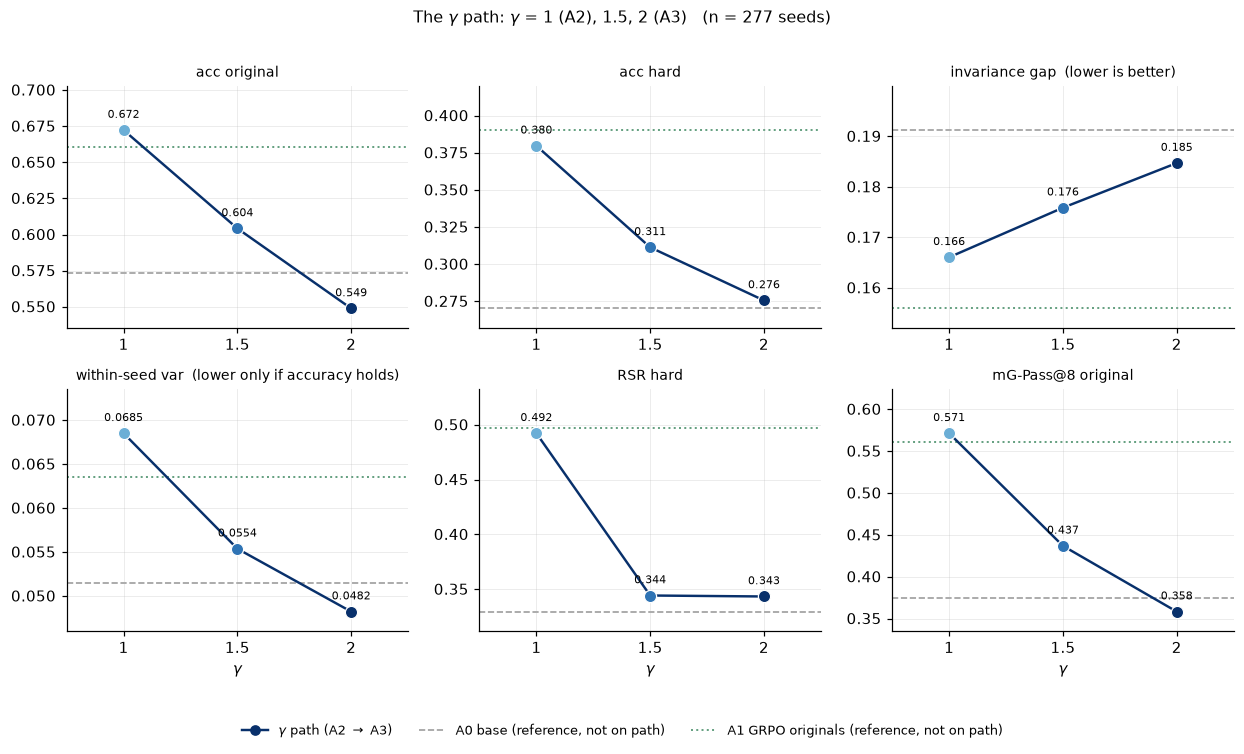

                    gamma=1 (A2)  gamma=1.5 (A3g1.5)  gamma=2 (A3)  A0 (ref)  A1 (ref)
acc original              0.6723              0.6042        0.5488    0.5730    0.6603
acc hard                  0.3797              0.3113        0.2756    0.2702    0.3902
invariance gap            0.1660              0.1759        0.1847    0.1912    0.1559
within-seed var           0.0685              0.0554        0.0482    0.0515    0.0635
RSR hard                  0.4922              0.3443        0.3434    0.3295    0.4974
mG-Pass@8 original        0.5713              0.4368        0.3583    0.3745    0.5614

trend along gamma:
  acc original         monotone DOWN   share of the A0->A2 difference undone:  gamma=1.5:    69%   gamma=2:   124%
  acc hard             monotone DOWN   share of the A0->A2 difference undone:  gamma=1.5:    62%   gamma=2:    95%
  invariance gap       monotone UP     share of the A0->A2 difference undone:  gamma=1.5:    39%   gamma=2:    74%
  within-seed var      mon

In [24]:
GP_METRICS = [
    ("acc original",        lambda r: cluster_bootstrap(ACC[r]["original"])["mean"],  "higher"),
    ("acc hard",            lambda r: cluster_bootstrap(ACC[r]["hard"])["mean"],      "higher"),
    ("invariance gap",      lambda r: cluster_bootstrap(GAP_ALL[r])["mean"],          "lower"),
    ("within-seed var",     lambda r: cluster_bootstrap(WVAR[r])["mean"],             "lower*"),
    ("RSR hard",            lambda r: RESULTS["fig5_rsr"][r]["hard"]["mean"],         "higher"),
    ("mG-Pass@8 original",  lambda r: RESULTS["fig9_mgpass8"][f"{r}|original"]["mean"], "higher"),
]

GPV = {name: {r: fn(r) for r in ORDER} for name, fn, _ in GP_METRICS}
gammas = sorted(GAMMA_PATH)

fig, axes = plt.subplots(2, 3, figsize=(11.4, 6.4))
for ax, (name, _, better) in zip(axes.ravel(), GP_METRICS):
    ys = [GPV[name][GAMMA_PATH[g]] for g in gammas]
    ax.plot(gammas, ys, "-", color="#08306B", lw=1.6, zorder=2)
    for g, y in zip(gammas, ys):
        ax.plot(g, y, "o", ms=8, color=COLOR[GAMMA_PATH[g]], zorder=3,
                markeredgecolor="white", markeredgewidth=0.8)
        ax.annotate(f"{y:.3f}" if name != "within-seed var" else f"{y:.4f}", (g, y),
                    xytext=(0, 8), textcoords="offset points", ha="center", fontsize=7.4)
    ax.axhline(GPV[name]["A0"], color="#9E9E9E", ls="--", lw=1.1, zorder=1)
    ax.axhline(GPV[name]["A1"], color="#66A182", ls=":", lw=1.3, zorder=1)
    ax.set_xticks(gammas); ax.set_xticklabels([f"{g:g}" for g in gammas])
    ax.set_xlim(gammas[0] - 0.25, gammas[-1] + 0.25)
    lo_, hi_ = ax.get_ylim(); pad = (hi_ - lo_) * 0.18
    ax.set_ylim(lo_ - pad * 0.3, hi_ + pad)
    ax.set_title(name + ("  (lower is better)" if better == "lower" else
                         "  (lower only if accuracy holds)" if better == "lower*" else ""),
                 fontsize=9)
for ax in axes[1]:
    ax.set_xlabel("$\\gamma$")
handles = [Line2D([], [], color="#08306B", marker="o", lw=1.6, label="$\\gamma$ path (A2 $\\rightarrow$ A3)"),
           Line2D([], [], color="#9E9E9E", ls="--", lw=1.1, label="A0 base (reference, not on path)"),
           Line2D([], [], color="#66A182", ls=":", lw=1.3, label="A1 GRPO originals (reference, not on path)")]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04), fontsize=8.5)
fig.suptitle(f"The $\\gamma$ path: $\\gamma$ = 1 (A2), 1.5, 2 (A3)   (n = {len(SHARED)} seeds)",
             y=1.01, fontsize=10.5)
fig.tight_layout(rect=(0, 0.04, 1, 1)); savefig(fig, "fig13_gamma_path"); plt.show()

GP_TAB = pd.DataFrame({f"gamma={g:g} ({GAMMA_PATH[g]})": {n: GPV[n][GAMMA_PATH[g]] for n, _, _ in GP_METRICS}
                       for g in gammas})
GP_TAB["A0 (ref)"] = [GPV[n]["A0"] for n, _, _ in GP_METRICS]
GP_TAB["A1 (ref)"] = [GPV[n]["A1"] for n, _, _ in GP_METRICS]
print(GP_TAB.round(4).to_string())

def trend(vals):
    d = np.diff(vals)
    if (d < 0).all(): return "monotone DOWN"
    if (d > 0).all(): return "monotone UP"
    return "non-monotone"

GP_TREND = {n: trend([GPV[n][GAMMA_PATH[g]] for g in gammas]) for n, _, _ in GP_METRICS}
# fraction of the A0 -> A2 gain given back at each step along the path
GIVEBACK = {}
for n, _, _ in GP_METRICS:
    gain = GPV[n]["A2"] - GPV[n]["A0"]
    GIVEBACK[n] = {f"{g:g}": ((GPV[n]["A2"] - GPV[n][GAMMA_PATH[g]]) / gain if abs(gain) > 1e-9 else np.nan)
                   for g in gammas}
print("\ntrend along gamma:")
for n in GP_TREND:
    gb = GIVEBACK[n]
    print(f"  {n:<20} {GP_TREND[n]:<15} share of the A0->A2 difference undone:  "
          + "   ".join(f"gamma={g}: {100*v:5.0f}%" for g, v in gb.items() if g != "1"))
RESULTS["fig13_gamma_path"] = {"values": GP_TAB.to_dict("index"), "trend": GP_TREND,
                               "share_of_A0_to_A2_undone": GIVEBACK, "gammas": gammas,
                               "path": {f"{g:g}": r for g, r in GAMMA_PATH.items()}}

---
## Figure 14 — The γ trade-off, smoothed

**Shows.** Accuracy across original → simple → hard for the three γ-path runs
(γ = 1, 1.5, 2), all in one panel, with A0 dashed grey as a reference. Each curve is a
**monotone piecewise-cubic (PCHIP) interpolant** through that run's three arm
accuracies: it passes through every measured point and cannot overshoot them. A
quadratic through three points was tried first and rejected — it bowed *upward*
between original and simple, implying accuracy rises under a small perturbation, which
no run shows. The x-axis is ordinal (surface change, then structural change); equal
spacing between the arms is a display choice, not a measured distance.

**Conclude.** This is the Rothenhäusler-style picture on MATH-Perturb. A genuine
accuracy-for-robustness trade-off would show a larger γ starting lower on the originals
but falling off less steeply, so the curves converge or cross towards *hard*. Parallel
curves that simply sit lower as γ rises mean the penalty lowered everything by a similar
amount — levelling down. The spread between curves at each arm is printed below.

saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig14_gamma_tradeoff_smoothed.{pdf,png}


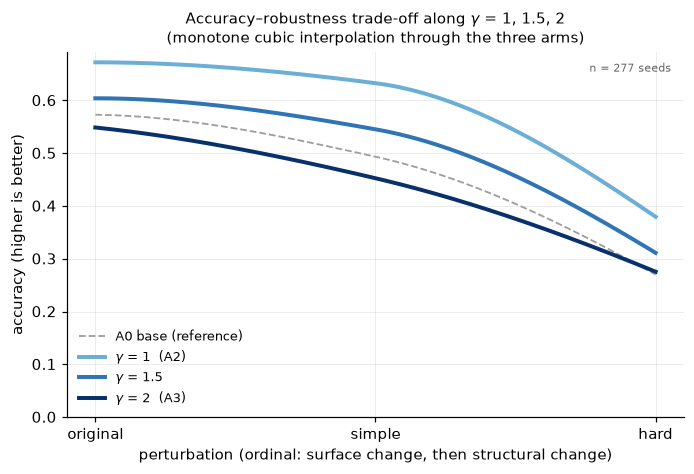


accuracy at each arm, and the gap to gamma = 1:
  gamma     original    simple      hard    orig-hard drop
  1            0.672     0.633     0.380             0.293
  1.5          0.604     0.545     0.311             0.293    vs gamma=1: -0.068 / -0.087 / -0.068
  2            0.549     0.453     0.276             0.273    vs gamma=1: -0.123 / -0.180 / -0.104

Does the curve converge on gamma = 1 towards 'hard'?  (positive = closes the distance)
  (for scale: re-running the A3 evaluation alone moved acc(hard) by 0.016)
  gamma=1.5: -0.000  -> below gamma = 1 at every arm; convergence of -0.000 is comparable to eval-rerun noise (0.016/arm) -> levelling down, not a trade-off
  gamma=2: +0.019  -> below gamma = 1 at every arm; convergence of +0.019 is comparable to eval-rerun noise (0.016/arm) -> levelling down, not a trade-off


In [25]:
X_ARMS = np.array([0.0, 1.0, 2.0])                          # original, simple, hard

from scipy.interpolate import PchipInterpolator

fig, ax = plt.subplots(figsize=(6.4, 4.4))
xs = np.linspace(0, 2, 300)
ref = np.array([F1["A0"][i]["mean"] for i in range(3)])
ax.plot(xs, PchipInterpolator(X_ARMS, ref)(xs), "--", color="#9E9E9E", lw=1.2,
        zorder=1, label="A0 base (reference)")

SMOOTH_MP = {}
for g, run in GAMMA_PATH.items():
    y = np.array([F1[run][i]["mean"] for i in range(3)])
    interp = PchipInterpolator(X_ARMS, y)
    SMOOTH_MP[run] = {"gamma": g, "acc": y}
    ax.plot(xs, interp(xs), "-", color=COLOR[run], lw=2.6, zorder=3,
            label=f"$\\gamma$ = {g:g}" + ("  (A2)" if run == "A2" else "  (A3)" if run == "A3" else ""))

ax.set_xticks(X_ARMS); ax.set_xticklabels(["original", "simple", "hard"])
ax.set_xlabel("perturbation (ordinal: surface change, then structural change)")
ax.set_ylabel("accuracy (higher is better)")
ax.set_ylim(bottom=0)
ax.legend(fontsize=8.5, loc="lower left")
ax.text(0.98, 0.97, f"n = {len(SHARED)} seeds", transform=ax.transAxes, ha="right", va="top",
        fontsize=7, color="#666")
ax.set_title("Accuracy–robustness trade-off along $\\gamma$ = 1, 1.5, 2\n"
             "(monotone cubic interpolation through the three arms)", fontsize=10)
fig.tight_layout(); savefig(fig, "fig14_gamma_tradeoff_smoothed")
plt.show()

print("\naccuracy at each arm, and the gap to gamma = 1:")
print(f"  {'gamma':<8}{'original':>10}{'simple':>10}{'hard':>10}   {'orig-hard drop':>15}")
base = SMOOTH_MP["A2"]["acc"]
for run, f in SMOOTH_MP.items():
    a = f["acc"]
    print(f"  {f['gamma']:<8g}{a[0]:>10.3f}{a[1]:>10.3f}{a[2]:>10.3f}   {a[0]-a[2]:>15.3f}"
          + ("" if run == "A2" else
             f"    vs gamma=1: {a[0]-base[0]:+.3f} / {a[1]-base[1]:+.3f} / {a[2]-base[2]:+.3f}"))
narrows = {run: (SMOOTH_MP[run]["acc"][2] - base[2]) - (SMOOTH_MP[run]["acc"][0] - base[0])
           for run in SMOOTH_MP if run != "A2"}
noise = float(RERUN_NOISE["acc hard"])   # one eval re-run moved acc(hard) by this much
print("\nDoes the curve converge on gamma = 1 towards 'hard'?  (positive = closes the distance)")
print(f"  (for scale: re-running the A3 evaluation alone moved acc(hard) by {noise:.3f})")
for run, v in narrows.items():
    below_everywhere = bool((SMOOTH_MP[run]["acc"] < base).all())
    # the convergence is a difference of two arms, so it carries at least the noise of
    # one re-run on each: require it to clear twice the single-arm re-run shift.
    if below_everywhere and v <= 2 * noise:
        verdict = (f"below gamma = 1 at every arm; convergence of {v:+.3f} is comparable to "
                   f"eval-rerun noise ({noise:.3f}/arm) -> levelling down, not a trade-off")
    elif below_everywhere:
        verdict = "below gamma = 1 at every arm but converging well beyond noise -> partial trade-off shape"
    else:
        verdict = "crosses gamma = 1 -> a genuine trade-off shape"
    print(f"  gamma={SMOOTH_MP[run]['gamma']:g}: {v:+.3f}  -> {verdict}")
RESULTS["fig14_smoothed_tradeoff"] = {
    f"{f['gamma']:g}": {"run": run, "curve": "PCHIP through the three arms",
                        "acc_original_simple_hard": [float(v) for v in f["acc"]],
                        "convergence_towards_hard_vs_gamma1": (float(narrows[run]) if run in narrows else None)}
    for run, f in SMOOTH_MP.items()}

---
## 5. Paired statistical tests

All contrasts run on the 277 seeds shared by all five runs, resampling seeds with
`B = 10,000`, `seed = 0`.

* **A3 − A2 on the gap is the hypothesis test.** An interval excluding zero is the
  evidence GRIP changed invariance.
* **A3 − A0 on accuracy is the levelling-down test.** An interval containing zero means
  A3 is statistically indistinguishable from the untrained model.
* **A3 − A0 on within-seed variance** is the confirmation: if that also contains zero,
  the variance reduction was a return to baseline, not an improvement.

In [26]:
CONTRASTS = [("A1", "A0"), ("A2", "A0"), ("A2", "A1"),
             ("A3g1.5", "A2"), ("A3", "A2"), ("A3", "A3g1.5"),
             ("A3g1.5", "A0"), ("A3", "A0")]

rows = []
for a, b in CONTRASTS:
    na, da = rsr_parts(a, "hard")[0]; nb, db = rsr_parts(b, "hard")[0]
    nsa, dsa = rsr_parts(a, "simple")[0]; nsb, dsb = rsr_parts(b, "simple")[0]
    rows.append({
        "contrast": f"{a} - {b}",
        "d_gap":        paired_cluster_bootstrap(GAP_ALL[a], GAP_ALL[b], SHARED),
        "d_acc_orig":   paired_cluster_bootstrap(ACC[a]["original"], ACC[b]["original"], SHARED),
        "d_acc_simple": paired_cluster_bootstrap(ACC[a]["simple"], ACC[b]["simple"], SHARED),
        "d_acc_hard":   paired_cluster_bootstrap(ACC[a]["hard"], ACC[b]["hard"], SHARED),
        "d_within_var": paired_cluster_bootstrap(WVAR[a], WVAR[b], SHARED),
        "d_rsr_hard":   paired_ratio_cluster_bootstrap(na, da, nb, db),
        "d_rsr_simple": paired_ratio_cluster_bootstrap(nsa, dsa, nsb, dsb),
    })

print(f"{'contrast':<12}{'n':>5}   {'Δ gap':<28}{'Δ acc(orig)':<28}{'Δ RSR-hard':<28}")
print("-" * 101)
for r in rows:
    print(f"{r['contrast']:<12}{r['d_gap']['n']:>5}   "
          f"{fmt_ci(r['d_gap']) + star(r['d_gap']):<28}"
          f"{fmt_ci(r['d_acc_orig']) + star(r['d_acc_orig']):<28}"
          f"{fmt_ci(r['d_rsr_hard']) + star(r['d_rsr_hard']):<28}")
print("\n*  interval excludes zero")
CONTRAST_ROWS = rows
RESULTS["contrasts"] = rows

contrast        n   Δ gap                       Δ acc(orig)                 Δ RSR-hard                  
-----------------------------------------------------------------------------------------------------
A1 - A0       277   -0.035 [-0.070, -0.001] *   0.087 [0.055, 0.120] *      0.168 [0.099, 0.237] *      
A2 - A0       277   -0.025 [-0.060, 0.009]      0.099 [0.067, 0.131] *      0.163 [0.090, 0.236] *      
A2 - A1       277   0.010 [-0.016, 0.036]       0.012 [-0.008, 0.033]       -0.005 [-0.066, 0.055]      
A3g1.5 - A2   277   0.010 [-0.022, 0.043]       -0.068 [-0.097, -0.039] *   -0.148 [-0.217, -0.077] *   
A3 - A2       277   0.019 [-0.018, 0.056]       -0.123 [-0.160, -0.087] *   -0.149 [-0.218, -0.080] *   
A3 - A3g1.5   277   0.009 [-0.023, 0.041]       -0.055 [-0.083, -0.028] *   -0.001 [-0.065, 0.063]      
A3g1.5 - A0   277   -0.015 [-0.044, 0.013]      0.031 [0.006, 0.057] *      0.015 [-0.043, 0.072]       
A3 - A0       277   -0.007 [-0.036, 0.022]      -0.024 [-0

In [27]:
h_gap = next(r for r in rows if r["contrast"] == "A3 - A2")["d_gap"]
h_acc = next(r for r in rows if r["contrast"] == "A3 - A0")["d_acc_orig"]
h_var = next(r for r in rows if r["contrast"] == "A3 - A0")["d_within_var"]

print("HYPOTHESIS TEST  --  A3 - A2 on the invariance gap")
print(f"  Δ gap = {fmt_ci(h_gap)}   (n = {h_gap['n']} paired seeds)")
print("  " + ("The interval EXCLUDES zero: GRIP measurably changed the invariance gap "
              f"({'reduced' if h_gap['mean'] < 0 else 'increased'} it)."
              if h_gap["significant"] else
              "The interval CONTAINS zero: at gamma = 2, GRIP did not measurably change the "
              "invariance gap relative to plain GRPO trained on the same data."))

print("\nLEVELLING-DOWN TEST  --  A3 - A0 on accuracy over originals")
print(f"  Δ acc(orig) = {fmt_ci(h_acc)}   (n = {h_acc['n']} paired seeds)")
print("  " + ("The interval EXCLUDES zero: A3 is distinguishable from the untrained model."
              if h_acc["significant"] else
              "The interval CONTAINS zero: A3 is statistically INDISTINGUISHABLE from the "
              "untrained base model on capability."))

print("\nCONFIRMATION  --  A3 - A0 on within-seed variance")
print(f"  Δ within-var = {fmt_ci(h_var, 4)}   (n = {h_var['n']} paired seeds)")
print("  " + ("The interval CONTAINS zero: A3's variance is indistinguishable from the untrained "
              "model's, so the reduction relative to A2 was a RETURN TO BASELINE rather than an "
              "improvement in invariance."
              if not h_var["significant"] else
              "The interval EXCLUDES zero: A3's variance genuinely differs from the untrained model's."))
print("\nTHE SAME THREE TESTS AT gamma = 1.5")
for lab, key, field, p in [("A3(g1.5) - A2  gap", "A3g1.5 - A2", "d_gap", 3),
                           ("A3(g1.5) - A0  acc(orig)", "A3g1.5 - A0", "d_acc_orig", 3),
                           ("A3(g1.5) - A0  within-var", "A3g1.5 - A0", "d_within_var", 4)]:
    d = next(r for r in rows if r["contrast"] == key)[field]
    print(f"  {lab:<28} {fmt_ci(d, p)}   {'EXCLUDES zero' if d['significant'] else 'contains zero'}")
RESULTS["hypothesis_test_gap_A3_A2"] = h_gap
RESULTS["levelling_down_test_acc_A3_A0"] = h_acc
RESULTS["variance_baseline_test_A3_A0"] = h_var

HYPOTHESIS TEST  --  A3 - A2 on the invariance gap
  Δ gap = 0.019 [-0.018, 0.056]   (n = 277 paired seeds)
  The interval CONTAINS zero: at gamma = 2, GRIP did not measurably change the invariance gap relative to plain GRPO trained on the same data.

LEVELLING-DOWN TEST  --  A3 - A0 on accuracy over originals
  Δ acc(orig) = -0.024 [-0.050, 0.001]   (n = 277 paired seeds)
  The interval CONTAINS zero: A3 is statistically INDISTINGUISHABLE from the untrained base model on capability.

CONFIRMATION  --  A3 - A0 on within-seed variance
  Δ within-var = -0.0033 [-0.0102, 0.0035]   (n = 277 paired seeds)
  The interval CONTAINS zero: A3's variance is indistinguishable from the untrained model's, so the reduction relative to A2 was a RETURN TO BASELINE rather than an improvement in invariance.

THE SAME THREE TESTS AT gamma = 1.5
  A3(g1.5) - A2  gap           0.010 [-0.022, 0.043]   contains zero
  A3(g1.5) - A0  acc(orig)     0.031 [0.006, 0.057]   EXCLUDES zero
  A3(g1.5) - A0  within-va

---
## 6. Tables

Each table is emitted as printed markdown **and** as `booktabs` LaTeX written to
`figures/`.

In [28]:
def to_latex(df, caption, label, bold_best=None, float_fmt="{:.3f}"):
    d = df.copy(); best = {}
    if bold_best:
        for c, how in bold_best.items():
            if c in d.columns:
                num = pd.to_numeric(d[c], errors="coerce")
                if num.notna().any():
                    best[c] = num.idxmax() if how == "max" else num.idxmin()
    def cell(idx, c, v):
        s = float_fmt.format(v) if isinstance(v, (int, float, np.floating)) and not isinstance(v, bool) else str(v)
        return r"\textbf{" + s + "}" if best.get(c) == idx else s
    lines = [r"\begin{table}[t]", r"\centering", r"\small",
             r"\begin{tabular}{l" + "r" * len(d.columns) + "}", r"\toprule",
             " & ".join([d.index.name or ""] + [str(c) for c in d.columns]) + r" \\", r"\midrule"]
    for idx, row in d.iterrows():
        lines.append(" & ".join([str(idx)] + [cell(idx, c, row[c]) for c in d.columns]) + r" \\")
    lines += [r"\bottomrule", r"\end{tabular}", r"\caption{" + caption + "}",
              r"\label{" + label + "}", r"\end{table}"]
    return "\n".join(lines)


def to_markdown(df, float_fmt="{:.3f}"):
    d = df.copy()
    for c in d.columns:
        d[c] = [float_fmt.format(v) if isinstance(v, (int, float, np.floating))
                and not isinstance(v, bool) else str(v) for v in d[c]]
    return d.to_markdown()


def emit(df, name, caption, label, bold_best=None, float_fmt="{:.3f}"):
    print(f"\n{'=' * 78}\n{name}\n{'=' * 78}")
    print(to_markdown(df, float_fmt))
    print("\n--- LaTeX ---")
    tex = to_latex(df, caption, label, bold_best, float_fmt)
    print(tex)
    with open(os.path.join(FIGDIR, f"{label.replace(':', '_')}.tex"), "w") as f:
        f.write(tex)
    return tex

In [29]:
# ── Table 1: main results ────────────────────────────────────────────────────
t1 = []
for r in ORDER:
    gap = cluster_bootstrap(GAP_ALL[r])
    t1.append({
        "acc(original)": cluster_bootstrap(ACC[r]["original"])["mean"],
        "acc(simple)":   cluster_bootstrap(ACC[r]["simple"])["mean"],
        "acc(hard)":     cluster_bootstrap(ACC[r]["hard"])["mean"],
        "gap $\\Delta$": gap["mean"],
        "gap 95% CI":    f"[{gap['lo']:.3f}, {gap['hi']:.3f}]",
        "within-seed var": cluster_bootstrap(WVAR[r])["mean"],
        "RSR simple":    RESULTS["fig5_rsr"][r]["simple"]["mean"],
        "RSR hard":      RESULTS["fig5_rsr"][r]["hard"]["mean"],
        "$\\hat{R}$ global": float(R8[(R8.run == r) & (R8.slice == "r_hat global (analogue)")].r_hat.iloc[0]),
        "mG-Pass@8 orig": RESULTS["fig9_mgpass8"][f"{r}|original"]["mean"],
        "frac fully inv.": float((GR[GR.run == r].c_corr == 1.0).mean()),
    })
T1 = pd.DataFrame(t1, index=ORDER); T1.index.name = "run"
emit(T1, "Table 1 -- main results",
     "MATH-Perturb main results on the 277 seeds shared by all five runs. Accuracy per arm, "
     "the invariance gap with its 95\\% cluster-bootstrap interval over seeds, within-seed "
     "variance, relative success rate per arm, global $\\hat{R}$ (an analogue -- see Fig.~8), "
     "mG-Pass@8 on originals, and the fraction of fully invariant seeds. Best per column in "
     "bold, except within-seed variance, which is left unbolded because a lower value is only "
     "better if accuracy holds -- at A3 it does not (Fig.~\\ref{fig:mp_variance}).",
     "tab:mp_main",
     # within-seed variance is deliberately left unbolded: a lower value is only better
     # if accuracy holds, and at A3 it does not (see the variance figure).
     bold_best={"acc(original)": "max", "acc(simple)": "max", "acc(hard)": "max",
                "gap $\\Delta$": "min", "RSR simple": "max",
                "RSR hard": "max", "$\\hat{R}$ global": "max", "mG-Pass@8 orig": "max",
                "frac fully inv.": "max"})
RESULTS["table1"] = T1.to_dict("index")


Table 1 -- main results
| run    |   acc(original) |   acc(simple) |   acc(hard) |   gap $\Delta$ | gap 95% CI     |   within-seed var |   RSR simple |   RSR hard |   $\hat{R}$ global |   mG-Pass@8 orig |   frac fully inv. |
|:-------|----------------:|--------------:|------------:|---------------:|:---------------|------------------:|-------------:|-----------:|-------------------:|-----------------:|------------------:|
| A0     |           0.573 |         0.493 |       0.27  |          0.191 | [0.155, 0.227] |             0.052 |        0.739 |      0.33  |              0.579 |            0.375 |             0.462 |
| A1     |           0.66  |         0.618 |       0.39  |          0.156 | [0.122, 0.191] |             0.064 |        0.834 |      0.497 |              0.594 |            0.561 |             0.502 |
| A2     |           0.672 |         0.633 |       0.38  |          0.166 | [0.130, 0.202] |             0.069 |        0.891 |      0.492 |              0.599 |          

In [30]:
# ── Table 2: outcome taxonomy ────────────────────────────────────────────────
t2 = {}
for r in ORDER:
    row = {}
    for key, lab, _ in PATTERNS:
        n = TAX[r].get(key, 0)
        row[lab + "  n"] = n
        row[lab + "  %"] = (100 * n / solved[r]) if key[0] == 1 else (100 * n / len(SHARED))
    row["solved originally"] = solved[r]
    t2[r] = row
T2 = pd.DataFrame(t2).T; T2.index.name = "run"
emit(T2, "Table 2 -- outcome taxonomy",
     "Per-seed outcome taxonomy $(e_i, h_{simple}, h_{hard})$. Percentages are of seeds "
     "\\emph{solved originally}, except the $0,*,*$ bucket which is of all seeds. The "
     "$1,1,0$ row is the technique-memorisation signature: solved the original and the "
     "surface perturbation, failed the structural one.",
     "tab:mp_taxonomy", float_fmt="{:.1f}")
RESULTS["table2"] = T2.to_dict("index")


Table 2 -- outcome taxonomy
| run    |   1,1,1  robust  n |   1,1,1  robust  % |   1,1,0  technique memorisation  n |   1,1,0  technique memorisation  % |   1,0,0  brittle  n |   1,0,0  brittle  % |   1,0,1  inconsistent  n |   1,0,1  inconsistent  % |   0,*,*  original not solved  n |   0,*,*  original not solved  % |   solved originally |
|:-------|-------------------:|-------------------:|-----------------------------------:|-----------------------------------:|--------------------:|--------------------:|-------------------------:|-------------------------:|--------------------------------:|--------------------------------:|--------------------:|
| A0     |                 55 |               31.2 |                                 75 |                               42.6 |                  43 |                24.4 |                        3 |                      1.7 |                             101 |                            36.5 |                 176 |
| A1     |                

In [31]:
# ── Table 3: paired contrasts ────────────────────────────────────────────────
T3 = pd.DataFrame([{
    "n seeds": r["d_gap"]["n"],
    "$\\Delta$ gap": fmt_ci(r["d_gap"]) + star(r["d_gap"]),
    "$\\Delta$ acc(orig)": fmt_ci(r["d_acc_orig"]) + star(r["d_acc_orig"]),
    "$\\Delta$ acc(hard)": fmt_ci(r["d_acc_hard"]) + star(r["d_acc_hard"]),
    "$\\Delta$ RSR-hard": fmt_ci(r["d_rsr_hard"]) + star(r["d_rsr_hard"]),
    "$\\Delta$ within-var": fmt_ci(r["d_within_var"], 4) + star(r["d_within_var"]),
} for r in CONTRAST_ROWS], index=[r["contrast"] for r in CONTRAST_ROWS])
T3.index.name = "contrast"
emit(T3, "Table 3 -- paired contrasts",
     "Paired seed-level cluster bootstrap (B=10{,}000, seed 0) over the 277 shared seeds. "
     "Intervals marked $*$ exclude zero. \\textbf{A3 $-$ A2 on the gap is the hypothesis "
     "test}; A3 $-$ A0 on accuracy is the levelling-down test, and A3 $-$ A0 on within-seed "
     "variance confirms whether the variance reduction was a return to baseline.",
     "tab:mp_contrasts")
RESULTS["table3"] = T3.to_dict("index")


Table 3 -- paired contrasts
| contrast    |   n seeds | $\Delta$ gap              | $\Delta$ acc(orig)        | $\Delta$ acc(hard)        | $\Delta$ RSR-hard         | $\Delta$ within-var          |
|:------------|----------:|:--------------------------|:--------------------------|:--------------------------|:--------------------------|:-----------------------------|
| A1 - A0     |       277 | -0.035 [-0.070, -0.001] * | 0.087 [0.055, 0.120] *    | 0.120 [0.088, 0.154] *    | 0.168 [0.099, 0.237] *    | 0.0120 [0.0031, 0.0210] *    |
| A2 - A0     |       277 | -0.025 [-0.060, 0.009]    | 0.099 [0.067, 0.131] *    | 0.110 [0.077, 0.143] *    | 0.163 [0.090, 0.236] *    | 0.0170 [0.0070, 0.0270] *    |
| A2 - A1     |       277 | 0.010 [-0.016, 0.036]     | 0.012 [-0.008, 0.033]     | -0.011 [-0.038, 0.017]    | -0.005 [-0.066, 0.055]    | 0.0050 [-0.0028, 0.0128]     |
| A3g1.5 - A2 |       277 | 0.010 [-0.022, 0.043]     | -0.068 [-0.097, -0.039] * | -0.068 [-0.099, -0.038] * | -0.1

In [32]:
# ── Table 4: by subject ──────────────────────────────────────────────────────
t4 = {}
for s in order_subj:
    row = {"n": SUBJ_N[s]}
    for r in ORDER:
        i = order_subj.index(s)
        row[f"{r} gap-simple"] = SUBJ[(r, "simple")][i]["mean"]
        row[f"{r} gap-hard"]   = SUBJ[(r, "hard")][i]["mean"]
    row["thin (n<10)"] = "yes" if SUBJ_N[s] < THIN else ""
    t4[s] = row
T4 = pd.DataFrame(t4).T; T4.index.name = "subject (sorted by base acc on originals)"
emit(T4, "Table 4 -- by subject",
     "Invariance gap per subject and ablation, subjects ordered by base-model accuracy on "
     "originals. Subjects with fewer than 10 seeds are marked thin and should not be read "
     "as findings. All problems are MATH Level 5, so no by-level breakdown exists.",
     "tab:mp_subject")
RESULTS["table4"] = T4.to_dict("index")


Table 4 -- by subject
| subject (sorted by base acc on originals)   |   n |   A0 gap-simple |   A0 gap-hard |   A1 gap-simple |   A1 gap-hard |   A2 gap-simple |   A2 gap-hard |   A3g1.5 gap-simple |   A3g1.5 gap-hard |   A3 gap-simple |   A3 gap-hard | thin (n<10)   |
|:--------------------------------------------|----:|----------------:|--------------:|----------------:|--------------:|----------------:|--------------:|--------------------:|------------------:|----------------:|--------------:|:--------------|
| Algebra                                     |  79 |           0.108 |         0.454 |           0.089 |         0.405 |           0.09  |         0.432 |               0.101 |             0.45  |           0.118 |         0.444 |               |
| Prealgebra                                  |  34 |           0.052 |         0.273 |           0.076 |         0.375 |           0.059 |         0.368 |               0.008 |             0.264 |           0.014 |         0.27  |  

In [33]:
# ── Table 5: generation health and format decomposition ──────────────────────
t5 = {}
for r in ORDER:
    sub = IT[IT.run == r]
    row = {"extract-fail": float(sub.extract_fail_rate.mean()),
           "truncation": float(sub.truncation_rate.mean()),
           "format-ok": float(sub.format_ok_rate.mean()),
           "mean tokens": float(sub.mean_n_tokens_completion.mean())}
    for arm in ARMS:
        row[f"acc uncond ({arm})"] = DEC[(r, arm)]["acc_unconditional"]
        row[f"acc |parsed ({arm})"] = DEC[(r, arm)]["acc_given_parsed"]
    t5[r] = row
T5 = pd.DataFrame(t5).T; T5.index.name = "run"
emit(T5, "Table 5 -- generation health and format decomposition",
     "Generation health per ablation, with the unconditional accuracy "
     "($n_{correct}/n_{attempted}$, the headline number) beside the accuracy conditional on "
     "a parseable answer ($n_{correct}/n_{parseable}$, a diagnostic). Seeds are never "
     "filtered on truncation: a truncated answer is a genuine task failure and stays in the "
     "headline.",
     "tab:mp_health",
     bold_best={"extract-fail": "min", "truncation": "min", "format-ok": "max"},
     float_fmt="{:.4f}")
RESULTS["table5"] = T5.to_dict("index")


Table 5 -- generation health and format decomposition
| run    |   extract-fail |   truncation |   format-ok |   mean tokens |   acc uncond (original) |   acc |parsed (original) |   acc uncond (simple) |   acc |parsed (simple) |   acc uncond (hard) |   acc |parsed (hard) |
|:-------|---------------:|-------------:|------------:|--------------:|------------------------:|-------------------------:|----------------------:|-----------------------:|--------------------:|---------------------:|
| A0     |         0.0617 |       0.0253 |      0.9386 |       811.237 |                  0.5537 |                   0.5801 |                0.4734 |                 0.5041 |              0.2527 |               0.2742 |
| A1     |         0.0173 |       0.0057 |      0.9827 |       831.09  |                  0.6579 |                   0.6639 |                0.6146 |                 0.6265 |              0.3872 |               0.3967 |
| A2     |         0.0131 |       0.0059 |      0.9869 |       80

---
## 7. Written analysis

Generated from the computed values — every number is interpolated from the objects built
above and the qualitative verdicts are predicates over those same values, so the prose
cannot drift from the data.

In [34]:
def pct(x): return f"{100*x:.1f}%"
def sig(d): return "excludes zero" if d.get("significant") else "contains zero"

acc = {r: {a: cluster_bootstrap(ACC[r][a]) for a in ARMS} for r in ORDER}
gap = {r: cluster_bootstrap(GAP_ALL[r]) for r in ORDER}
wv  = {r: cluster_bootstrap(WVAR[r]) for r in ORDER}
av  = {r: cluster_bootstrap(ACC_PERT[r]) for r in ORDER}
C   = {r["contrast"]: r for r in CONTRAST_ROWS}
mem = RESULTS["fig6_memorisation_frac"]

# exact decomposition of the A2 -> A3 gap movement
d_go = C["A3 - A2"]["d_acc_orig"]["mean"]
d_gv = paired_cluster_bootstrap(ACC_PERT["A3"], ACC_PERT["A2"], SHARED)["mean"]
d_gg = C["A3 - A2"]["d_gap"]["mean"]
share_orig = abs(d_go) / max(abs(d_go) + abs(d_gv), 1e-12)
if d_go < 0 and d_gv < 0:
    DECOMP_SENTENCE = (
        f"Both ends fell, and the perturbed arms fell {'further' if abs(d_gv) > abs(d_go) else 'less far'} "
        f"than the originals ({abs(d_gv):.4f} against {abs(d_go):.4f}), which is why the gap "
        f"{'widened' if d_gg > 0 else 'narrowed'} rather than closing. The penalty did not lift the "
        "arms the model was failing -- it lowered everything, and lowered the arms it was already "
        "weakest on the most. A gap that moves because both ends collapse carries no information "
        "about invariance.")
elif d_go < 0 <= d_gv:
    DECOMP_SENTENCE = (
        f"The originals fell while the perturbed arms held or improved, so {100*share_orig:.0f}% of "
        "the movement in the gap comes from the originals: the penalty brought the originals down "
        "towards the arms rather than lifting the arms.")
else:
    DECOMP_SENTENCE = (
        f"The originals {'rose' if d_go > 0 else 'held'} while the perturbed arms moved by "
        f"{d_gv:+.4f}, so the gap change is driven from the perturbed side.")
print(f"gap decomposition A3-A2: d_gap {d_gg:+.4f} = d_acc_orig {d_go:+.4f} - d_acc_pert {d_gv:+.4f} "
      f"(|originals| share {100*share_orig:.0f}%)")
print("  ->", DECOMP_SENTENCE)
RESULTS["gap_decomposition_A3_A2"] = {"d_gap": d_gg, "d_acc_orig": d_go,
                                      "d_acc_perturbed": d_gv, "share_from_originals": share_orig}

levelling = (not C["A3 - A0"]["d_acc_orig"]["significant"]) and (d_go < 0)
var_baseline = not C["A3 - A0"]["d_within_var"]["significant"]
noise_med = float(RERUN_NOISE.median())

P = []
P.append(f'''
BASELINE AT A0

Before any training the base model solves {acc['A0']['original']['mean']:.3f} of the
MATH Level 5 originals, {acc['A0']['simple']['mean']:.3f} of the surface-perturbed
variants and {acc['A0']['hard']['mean']:.3f} of the structurally perturbed ones, an
invariance gap of {fmt_ci(gap['A0'])} over n = {gap['A0']['n']} seeds. The asymmetry
between the two perturbations is the benchmark's central quantity: the simple rewrite
costs {acc['A0']['original']['mean'] - acc['A0']['simple']['mean']:.3f} of accuracy while
the hard rewrite costs {acc['A0']['original']['mean'] - acc['A0']['hard']['mean']:.3f},
roughly {(acc['A0']['original']['mean'] - acc['A0']['hard']['mean']) / max(acc['A0']['original']['mean'] - acc['A0']['simple']['mean'], 1e-9):.1f} times
as much. Conditioning capability away, RSR is {RESULTS['fig5_rsr']['A0']['simple']['mean']:.3f}
on simple against {RESULTS['fig5_rsr']['A0']['hard']['mean']:.3f} on hard.

The taxonomy puts a number on what that asymmetry means. Of the {solved['A0']} seeds the
base model solved originally, {RESULTS['fig6_taxonomy']['A0']['(1, 1, 0)']} — {pct(mem['A0'])} —
were solved on the original and on the simple perturbation and then failed on the hard
one. That is the technique-memorisation signature the benchmark exists to produce: a
solution method that survives a rewrite preserving it and collapses when the method no
longer applies. Only {pct(RESULTS['fig6_taxonomy']['A0']['(1, 1, 1)'] / solved['A0'])} of
solved seeds were robust across all three arms.
''')

P.append(f'''
DID RL IMPROVE CAPABILITY, AND DID IT IMPROVE ROBUSTNESS (A0 -> A1)

GRPO on originals alone lifts accuracy on originals from {acc['A0']['original']['mean']:.3f}
to {acc['A1']['original']['mean']:.3f}, a paired difference of
{fmt_ci(C['A1 - A0']['d_acc_orig'])} whose interval {sig(C['A1 - A0']['d_acc_orig'])}. It
lifts the hard arm too, by {fmt_ci(C['A1 - A0']['d_acc_hard'])}. Unlike the ASyMOB runs,
robustness moved with capability here: the gap changed by {fmt_ci(C['A1 - A0']['d_gap'])},
an interval that {sig(C['A1 - A0']['d_gap'])}, and RSR on the hard arm rose by
{fmt_ci(C['A1 - A0']['d_rsr_hard'])}, {sig(C['A1 - A0']['d_rsr_hard'])}. Training on
originals alone therefore improved not just how much the model could solve but how much of
that survived a structural rewrite — and it did so without ever seeing a perturbation.
''')

P.append(f'''
DID AUGMENTATION CLOSE THE GAP FURTHER (A1 -> A2)

Adding every variant to the training mixture, objective unchanged, moves accuracy on
originals by {fmt_ci(C['A2 - A1']['d_acc_orig'])} ({sig(C['A2 - A1']['d_acc_orig'])}) and
the gap by {fmt_ci(C['A2 - A1']['d_gap'])} ({sig(C['A2 - A1']['d_gap'])}). RSR on the hard
arm changes by {fmt_ci(C['A2 - A1']['d_rsr_hard'])}. Augmentation therefore
{'did' if C['A2 - A1']['d_gap']['significant'] else 'did not'} measurably close the
invariance gap beyond what GRPO on originals already achieved — most of the robustness
gain on this benchmark was already bought by A1, and adding the perturbations to training
largely consolidated rather than extended it.
''')

P.append(f'''
DID THE GRIP PENALTY CLOSE IT FURTHER (A2 -> A3)

This is the thesis test, and the only contrast holding data and hyperparameters fixed
while the objective alone varies. The paired difference in the invariance gap is
{fmt_ci(C['A3 - A2']['d_gap'])} over n = {C['A3 - A2']['d_gap']['n']} shared seeds, and the
interval {sig(C['A3 - A2']['d_gap'])}.
{'GRIP therefore measurably changed the invariance gap.' if C['A3 - A2']['d_gap']['significant'] else 'At gamma = 2, GRIP did not measurably change the invariance gap relative to plain GRPO trained on the same data.'}
RSR on the hard arm moves by {fmt_ci(C['A3 - A2']['d_rsr_hard'])} and within-seed variance
by {fmt_ci(C['A3 - A2']['d_within_var'], 4)}.
''')

g15 = "A3g1.5"
steps = [(f"{a:g}", f"{b:g}", GAMMA_PATH[a], GAMMA_PATH[b]) for a, b in zip(gammas[:-1], gammas[1:])]
step_cost = {f"{a}->{b}": C[f"{rb} - {ra}"]["d_acc_orig"] for a, b, ra, rb in steps}
any_gap_gain = any(C[f"{GAMMA_PATH[g]} - A2"]["d_gap"]["significant"] and
                   C[f"{GAMMA_PATH[g]} - A2"]["d_gap"]["mean"] < 0 for g in gammas if g != 1.0)
g15_indist = not C[f"{g15} - A0"]["d_acc_orig"]["significant"]
P.append(f'''
THE GAMMA PATH: ONE, ONE-AND-A-HALF, TWO

The intermediate run turns the thesis test from a two-point comparison into a
dose-response. Along gamma = 1, 1.5 and 2, accuracy on originals runs
{' -> '.join(f"{GPV['acc original'][GAMMA_PATH[g]]:.3f}" for g in gammas)} ({GP_TREND['acc original'].lower()}),
accuracy on the hard arm {' -> '.join(f"{GPV['acc hard'][GAMMA_PATH[g]]:.3f}" for g in gammas)},
the invariance gap {' -> '.join(f"{GPV['invariance gap'][GAMMA_PATH[g]]:.3f}" for g in gammas)}
({GP_TREND['invariance gap'].lower()}), within-seed variance
{' -> '.join(f"{GPV['within-seed var'][GAMMA_PATH[g]]:.4f}" for g in gammas)}, and RSR on
the hard arm {' -> '.join(f"{GPV['RSR hard'][GAMMA_PATH[g]]:.3f}" for g in gammas)}.
Measured as a share of what separated A2 from the untrained model, gamma = 1.5 has
already undone {100*GIVEBACK['acc original']['1.5']:.0f}% of the gain on originals and
gamma = 2 undoes {100*GIVEBACK['acc original']['2']:.0f}%{' -- more than all of it, which is what it means to finish below the base model' if GIVEBACK['acc original']['2'] > 1 else ''}.

The paired tests locate the damage. At gamma = 1.5 the gap moves by
{fmt_ci(C[f'{g15} - A2']['d_gap'])} against gamma = 1, an interval that
{sig(C[f'{g15} - A2']['d_gap'])}, while accuracy on originals moves by
{fmt_ci(C[f'{g15} - A2']['d_acc_orig'])} ({sig(C[f'{g15} - A2']['d_acc_orig'])}). The first
half-step, 1 to 1.5, costs {fmt_ci(step_cost['1->1.5'])} on originals; the second, 1.5 to 2,
costs {fmt_ci(step_cost['1.5->2'])}. Against the untrained model, gamma = 1.5 stands at
{fmt_ci(C[f'{g15} - A0']['d_acc_orig'])} on originals, an interval that
{sig(C[f'{g15} - A0']['d_acc_orig'])}.
{'So at gamma = 1.5 the model is still measurably better than no training at all -- the collapse is progressive in gamma rather than a cliff, and gamma = 2 is where it reaches the base model.' if not g15_indist else 'So gamma = 1.5 is already indistinguishable from the untrained model: the collapse is complete by the midpoint of the path.'}
The two kinds of damage do not move together. RSR on the hard arm -- robustness with
capability conditioned away -- falls by {fmt_ci(C[f'{g15} - A2']['d_rsr_hard'])} over the
first half-step, an interval that {sig(C[f'{g15} - A2']['d_rsr_hard'])}, and then by
{fmt_ci(C[f'A3 - {g15}']['d_rsr_hard'])} over the second, which {sig(C[f'A3 - {g15}']['d_rsr_hard'])}.
{'The loss of structural robustness is therefore complete by gamma = 1.5, where RSR-hard is already back at the base model, while raw accuracy keeps sliding for the rest of the path. The penalty removes what training added to robustness first, and removes capability progressively afterwards.' if (C[f'{g15} - A2']['d_rsr_hard']['significant'] and not C[f'A3 - {g15}']['d_rsr_hard']['significant']) else ''}
{'No point on the path buys a measurable reduction in the invariance gap relative to gamma = 1, so there is no trade-off to optimise here: raising gamma spends capability and receives no invariance in exchange.' if not any_gap_gain else 'At least one point on the path does measurably reduce the gap, so there is a genuine trade-off to weigh against the capability it costs.'}
''')

P.append(f'''
THE CAPABILITY COST, AND WHETHER IT BOUGHT ANYTHING

The penalty was expensive. Accuracy on originals falls from {acc['A2']['original']['mean']:.3f}
at A2 to {acc['A3']['original']['mean']:.3f} at A3, a paired difference of
{fmt_ci(C['A3 - A2']['d_acc_orig'])} whose interval {sig(C['A3 - A2']['d_acc_orig'])}; the
hard arm falls by {fmt_ci(C['A3 - A2']['d_acc_hard'])}. Set against the untrained model,
A3 stands at {fmt_ci(C['A3 - A0']['d_acc_orig'])} on originals, an interval that
{sig(C['A3 - A0']['d_acc_orig'])}.
{'A3 is therefore statistically indistinguishable from the untrained base model on capability: the entire gain from reinforcement learning has been given back.' if not C['A3 - A0']['d_acc_orig']['significant'] else 'A3 therefore remains distinguishable from the untrained base model on capability.'}

Figures 3 and 4 together are what turn that from a description into a diagnosis. In
Figure 3, A3 sits at ({acc['A3']['original']['mean']:.3f}, {gap['A3']['mean']:.3f}) against
A2 at ({acc['A2']['original']['mean']:.3f}, {gap['A2']['mean']:.3f}) --
{'left of and below' if (acc['A3']['original']['mean'] < acc['A2']['original']['mean'] and gap['A3']['mean'] < gap['A2']['mean']) else 'left of and above' if acc['A3']['original']['mean'] < acc['A2']['original']['mean'] else 'right of'}
it, and essentially on top of A0.

The decomposition is exact, because the gap is a difference of two accuracies and can
move from either end: Delta-gap = Delta-acc(original) - Delta-acc(perturbed), here
{d_gg:+.4f} = {d_go:+.4f} - ({d_gv:+.4f}). Accuracy on the originals
{'rose' if d_go > 0 else 'fell'} by {abs(d_go):.4f} and accuracy on the perturbed arms
{'rose' if d_gv > 0 else 'fell'} by {abs(d_gv):.4f}.
{DECOMP_SENTENCE}
''')

P.append(f'''
THE WITHIN-VARIANCE TRAP, STATED EXPLICITLY

Read alone, A3's within-seed variance looks like the penalty working: {wv['A3']['mean']:.4f}
against A2's {wv['A2']['mean']:.4f}, a paired difference of
{fmt_ci(C['A3 - A2']['d_within_var'], 4)}. The trap is that A3's variance also matches the
*untrained* model's {wv['A0']['mean']:.4f}, and the paired test says so directly: A3 - A0
on within-seed variance is {fmt_ci(C['A3 - A0']['d_within_var'], 4)}, an interval that
{sig(C['A3 - A0']['d_within_var'])}.
{'Because that interval contains zero, the variance reduction was a RETURN TO BASELINE, not an improvement in invariance.' if var_baseline else 'That interval excludes zero, so A3 variance genuinely differs from the untrained baseline.'}
The accuracies confirm the mechanism: mean accuracy across the perturbed arms is
{av['A3']['mean']:.4f} at A3 against {av['A0']['mean']:.4f} at A0 and {av['A2']['mean']:.4f}
at A2. {'Variance fell because everything fell back to where it started. That is levelling down, and it is why the narrower gap at A3 must not be read as improved invariance.' if levelling else 'Variance fell without a matching collapse in accuracy, so this is not simply levelling down.'}
''')

P.append(f'''
DID THE MEMORISATION BUCKET SHRINK UNDER ANY TRAINING CONDITION

Technique memorisation, as a fraction of the seeds each model solved originally, runs
{', '.join(f"{r} {pct(mem[r])}" for r in ORDER)}. The paired contrasts on seeds solved
originally in both runs give A1 - A0 {fmt_ci(RESULTS['fig6_contrasts']['A1 - A0'])}, A2 - A1
{fmt_ci(RESULTS['fig6_contrasts']['A2 - A1'])}, A3 - A2
{fmt_ci(RESULTS['fig6_contrasts']['A3 - A2'])} and A3 - A0
{fmt_ci(RESULTS['fig6_contrasts']['A3 - A0'])}.
{'At least one training condition measurably reduced the memorisation bucket.' if any(RESULTS['fig6_contrasts'][k]['significant'] for k in RESULTS['fig6_contrasts']) else 'No training condition measurably reduced the memorisation bucket: every interval contains zero.'}
That null is not the whole story, though, and the rest of the taxonomy is where the
training actually shows. Among seeds solved originally, the fully robust bucket runs
{', '.join(f"{r} {pct(RESULTS['fig6_taxonomy'][r]['(1, 1, 1)'] / solved[r])}" for r in ORDER)}
and the brittle bucket — solved the original and nothing else — runs
{', '.join(f"{r} {pct(RESULTS['fig6_taxonomy'][r]['(1, 0, 0)'] / solved[r])}" for r in ORDER)}.
The paired contrasts confirm the shift: A1 − A0 on the robust bucket is
{fmt_ci(TAXC['1,1,1 robust|A1 - A0'])} and on the brittle bucket
{fmt_ci(TAXC['1,0,0 brittle|A1 - A0'])}; both intervals exclude zero. A3 − A0
returns both to baseline: {fmt_ci(TAXC['1,1,1 robust|A3 - A0'])} robust,
{fmt_ci(TAXC['1,0,0 brittle|A3 - A0'])} brittle.

So reinforcement learning did change the *composition* of its successes — converting
brittle solves into robust ones — without changing the share that fail specifically at the
technique boundary. A model can become substantially better at Level 5 mathematics, and
substantially less brittle, while the proportion of its successes resting on a method that
breaks under a structural rewrite stays where it was. Figure 7 supports the same point from the
other direction: the hard arm is reliably harder on the *same* seed, not merely on
average, with {pct(HMS['A0']['frac_above'])} of A0's seeds above the diagonal against
{pct(HMS['A0']['frac_below'])} below and {pct(HMS['A0']['frac_equal'])} tied — so
{pct(HMS['A0']['above_of_untied'])} of the seeds that discriminate at all fall on the
hard-is-harder side — and the paired hard-minus-simple gap {fmt_ci(HMS['A0']['hms'])}, an
interval that {sig(HMS['A0']['hms'])}.
''')

P.append(f'''
RELIABILITY, SUBJECTS, AND GENERATION HEALTH AS A THREAT TO THE ABOVE

On reliability, mG-Pass@8 over originals runs
{', '.join(f"{r} {RESULTS['fig9_mgpass8'][r + '|original']['mean']:.3f}" for r in ORDER)}, and
the reliability deficit -- avg@8 minus mG-Pass@8, the capability that does not survive
being asked eight times -- is {RESULTS['fig9_reliability_deficit']['A0']['original']:.3f} at
A0 against {RESULTS['fig9_reliability_deficit']['A3']['original']:.3f} at A3 on the original
arm. A3's mG-Pass@8 on originals ({RESULTS['fig9_mgpass8']['A3|original']['mean']:.3f}) is
{'below' if RESULTS['fig9_mgpass8']['A3|original']['mean'] < RESULTS['fig9_mgpass8']['A0|original']['mean'] else 'above'}
the untrained model's ({RESULTS['fig9_mgpass8']['A0|original']['mean']:.3f}), so on solving
dependably rather than solving at all, the penalised run is no improvement on no training
at all. By subject, every bucket carries at least {min(SUBJ_N.values())} seeds, so none had
to be discounted as thin, and the ordering of gaps is broadly consistent across subjects
rather than driven by one topic.

Generation health is the threat that has to be disclosed rather than assumed away. A3's
extract-failure rate is {RESULTS['fig11_health']['A3']['extract_fail_rate']:.4f} against
A2's {RESULTS['fig11_health']['A2']['extract_fail_rate']:.4f} --
{RESULTS['fig11_health']['A3']['extract_fail_rate'] / max(RESULTS['fig11_health']['A2']['extract_fail_rate'], 1e-12):.1f} times
higher -- with truncation {RESULTS['fig11_health']['A3']['truncation_rate']:.4f} against
{RESULTS['fig11_health']['A2']['truncation_rate']:.4f} and mean completion
{RESULTS['fig11_health']['A3']['mean_n_tokens_completion']:.0f} tokens against
{RESULTS['fig11_health']['A2']['mean_n_tokens_completion']:.0f}. The direction reproduces
the ASyMOB pattern -- longer generations, more often hitting the token cap before a boxed
answer -- though at a far smaller magnitude than ASyMOB's 12.9x. The format decomposition
in Figure 11b separates the two explanations: on the original arm the unconditional
accuracy moves by {DEC[('A3','original')]['acc_unconditional'] - DEC[('A2','original')]['acc_unconditional']:+.4f}
from A2 to A3 while the accuracy conditional on a parseable answer moves by
{DEC[('A3','original')]['acc_given_parsed'] - DEC[('A2','original')]['acc_given_parsed']:+.4f}
and the format rate by {DEC[('A3','original')]['format_rate'] - DEC[('A2','original')]['format_rate']:+.4f}.
{'Since the conditional accuracy falls nearly as much as the unconditional one, the degradation is in reasoning, not merely in termination -- the format loss is real but it is not the explanation.' if abs(DEC[('A3','original')]['acc_given_parsed'] - DEC[('A2','original')]['acc_given_parsed']) > 0.5 * abs(DEC[('A3','original')]['acc_unconditional'] - DEC[('A2','original')]['acc_unconditional']) else 'Since the conditional accuracy holds up while the format rate falls, a substantial share of A3 measured drop is termination rather than reasoning.'}
Seeds on which A3 truncated are deliberately not excluded: truncation without an answer is
a genuine task failure, and filtering on it would condition on the outcome.

One further caveat applies specifically to A3. Its evaluation was re-run on 2026-09-18,
after the brief's headline table was written, with the same checkpoint, seed and sampling
settings; the two runs differ by a median of {noise_med:.4f} across the ten headline
metrics, with the largest single deviation {RERUN_NOISE.max():.4f} on
{RERUN_NOISE.idxmax()}. That is an empirical floor on eval-rerun noise, and any A3
contrast of comparable size should be treated as provisional.
''')

P.append(f'''
LIMITATIONS

The evidence base is {len(SHARED)} problems, all at MATH Level 5, so there is no
difficulty variation to exploit and no by-level breakdown is possible. It rests on a
single model scale (Qwen2.5-Math-1.5B); on one training seed per ablation, so between-run
training variability is unmeasured and the intervals here quantify only seed-level
sampling within a fixed set of checkpoints; on 500 training steps, which may be short of
convergence; and on three points of the gamma path (1, 1.5 and 2) -- enough to see the
direction and rough shape of the response, not enough to rule out a useful setting below
1.5, which is where the path would have to be sampled next. The A3 re-run above shows that evaluation itself contributes noise of
order {noise_med:.3f} on these metrics.

The last limitation is structural rather than empirical, and it is the one more compute
will not remove. A variance penalty on accuracy is capability-blind by construction: it
sees the spread of outcomes within a seed and nothing about their level, so it cannot
distinguish equalising upward -- lifting the arm the model fails -- from equalising
downward -- suppressing the arm it handles. The two are identical in the loss and opposite
in value. They are also not equally available to the optimiser, since suppressing a strong
arm is a cheaper gradient direction than mastering a weak one, so wherever the penalty is
strong enough to bind, the cheap direction is the one it will find.
{'That is what the measurements here show it doing.' if levelling else 'The measurements here do not settle which direction it took.'}
''')

print("\n\n".join(textwrap.dedent(p).strip() for p in P))

gap decomposition A3-A2: d_gap +0.0187 = d_acc_orig -0.1234 - d_acc_pert -0.1421 (|originals| share 46%)
  -> Both ends fell, and the perturbed arms fell further than the originals (0.1421 against 0.1234), which is why the gap widened rather than closing. The penalty did not lift the arms the model was failing -- it lowered everything, and lowered the arms it was already weakest on the most. A gap that moves because both ends collapse carries no information about invariance.
BASELINE AT A0

Before any training the base model solves 0.573 of the
MATH Level 5 originals, 0.493 of the surface-perturbed
variants and 0.270 of the structurally perturbed ones, an
invariance gap of 0.191 [0.155, 0.227] over n = 277 seeds. The asymmetry
between the two perturbations is the benchmark's central quantity: the simple rewrite
costs 0.080 of accuracy while
the hard rewrite costs 0.303,
roughly 3.8 times
as much. Conditioning capability away, RSR is 0.739
on simple against 0.330 on hard.

The taxonomy 

---
## Figure 15 — Does scale buy robustness? Base model at 1.5B vs 7B

**Shows.** The untrained base model at two scales — `Qwen2.5-Math-1.5B` (A0) and
`Qwen2.5-Math-7B` — across original → simple → hard. **Left**: absolute accuracy.
**Right**: accuracy as a fraction of each model's *own* accuracy on the originals, which
removes the capability difference and leaves only the shape of the degradation — the
robustness question. Smooth lines are monotone cubic interpolants through the three
measured arms (they pass through every point); values are annotated at each arm.

**Conclude.** If scale bought robustness, the 7B curve on the right would sit above the
1.5B curve and flatten towards *hard*. If the right-hand curves nearly coincide while the
left-hand curves are separated, scale lifted capability roughly uniformly and left the
brittleness profile where it was.

**What this figure does not show, and is reported below instead.** The normalised curves
and the invariance gap are one reading of robustness. RSR — the probability of solving a
perturbed variant *given the original was solved* — is another, and the paired tests
below report it separately rather than letting the figure speak for every measure.

The 7B run is loaded here only. It is not an ablation, so it is kept out of `RUNS` and
every other figure.

[1.5B] 277 groups   model = Qwen/Qwen2.5-Math-1.5B
[7B] 278 groups   model = Qwen/Qwen2.5-Math-7B
shared seeds: 277   dropped as unshared: {'1.5B': [], '7B': ['2184']}


saved  /home/amz/projects/GRIP/ablations/eval/math_perturb/figures/fig15_scale_1p5B_vs_7B.{pdf,png}


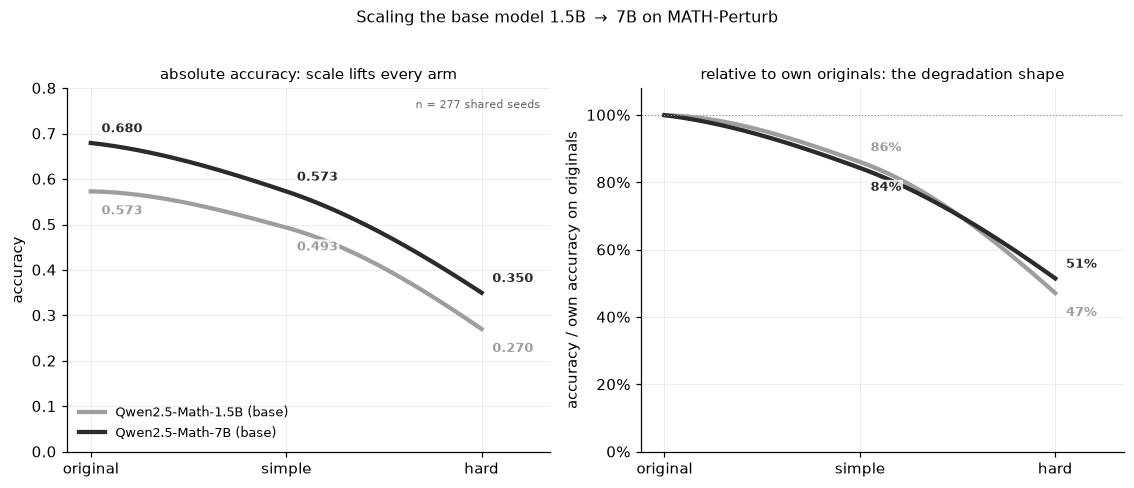


paired 7B - 1.5B on 277 shared seeds (B=10000, seed 0); * = interval excludes zero
  acc original     +0.106 [+0.078, +0.135] *
  acc simple       +0.080 [+0.050, +0.109] *
  acc hard         +0.080 [+0.054, +0.106] *
  invariance gap   +0.027 [-0.007, +0.061]
  retained simple  -0.018 [-0.080, +0.042]
  RSR simple       +0.021 [-0.043, +0.086]
  retained hard    +0.044 [-0.003, +0.089]
  RSR hard         +0.095 [+0.034, +0.157] *

levels:
  1.5B  acc 0.573 / 0.493 / 0.270   retained simple 86.1%, hard 47.1%
  7B    acc 0.680 / 0.573 / 0.350   retained simple 84.3%, hard 51.5%

VERDICT
  Capability: 7B is better on every arm (original +0.106, simple +0.080, hard +0.080).
  Gap: not reduced by scale -- the interval contains zero and the point estimate is larger at 7B.
  Degradation shape: both models keep roughly 47%-51% of their original accuracy on 'hard'; the difference is not significant.
  RSR-hard: SIGNIFICANTLY higher at 7B (+0.095). Conditioned on solving the original, the larg

In [35]:
from scipy.interpolate import PchipInterpolator

SCALE_RUNS = {"1.5B": RUNS["A0"], "7B": f"{BASE}/a0_mathperturb_7B_20260904"}
SCALE_COLOR = {"1.5B": "#9E9E9E", "7B": "#2B2B2B"}

SG = {}
for k, rd in SCALE_RUNS.items():
    if not os.path.isdir(rd):
        raise FileNotFoundError(f"[{k}] scale run directory missing: {rd}")
    SG[k] = {g["group_id"]: g for g in _jsonl(_locate(rd, "groups.jsonl"))}
    man = json.load(open(_locate(rd, "manifest.json")))
    print(f"[{k}] {len(SG[k])} groups   model = {man['model']['name']}")
SSEEDS = sorted(set(SG["1.5B"]) & set(SG["7B"]))
print(f"shared seeds: {len(SSEEDS)}   dropped as unshared: "
      f"{ {k: sorted(set(SG[k]) - set(SSEEDS)) for k in SG} }")

def sacc(k, arm):
    return np.array([SG[k][s]["acc_original"] if arm == "original" else SG[k][s]["acc_by_arm"][arm]
                     for s in SSEEDS], dtype=float)

SACC = {k: {a: sacc(k, a) for a in ARMS} for k in SCALE_RUNS}
MEAN = {k: np.array([SACC[k][a].mean() for a in ARMS]) for k in SCALE_RUNS}
NORM_S = {k: MEAN[k] / MEAN[k][0] for k in SCALE_RUNS}

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.3))
xa, xs = np.array([0.0, 1.0, 2.0]), np.linspace(0, 2, 300)
for ax, vals, ylab, fmt in [(axes[0], MEAN, "accuracy", "{:.3f}"),
                            (axes[1], NORM_S, "accuracy / own accuracy on originals", "{:.0%}")]:
    for k in SCALE_RUNS:
        ax.plot(xs, PchipInterpolator(xa, vals[k])(xs), "-", lw=2.8, color=SCALE_COLOR[k],
                label=f"Qwen2.5-Math-{k} (base)")
        for xi, v in zip(xa, vals[k]):
            if ax is axes[1] and xi == 0:
                continue
            # place each label on the side of its curve away from the other model's curve
            other = vals["1.5B" if k == "7B" else "7B"][int(xi)]
            above = v >= other
            ax.annotate(fmt.format(v), (xi, v), xytext=(7, 7 if above else -15),
                        textcoords="offset points", fontsize=8.2, color=SCALE_COLOR[k],
                        fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.85))
    ax.set_xticks(xa); ax.set_xticklabels(["original", "simple", "hard"])
    ax.set_xlim(-0.12, 2.35); ax.set_ylabel(ylab)
axes[0].set_ylim(0, 0.8); axes[0].set_title("absolute accuracy: scale lifts every arm", fontsize=9.5)
axes[1].set_ylim(0, 1.08); axes[1].axhline(1.0, color="#999", lw=0.8, ls=":")
axes[1].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
axes[1].set_title("relative to own originals: the degradation shape", fontsize=9.5)
axes[0].legend(fontsize=8.5, loc="lower left")
axes[0].text(0.98, 0.97, f"n = {len(SSEEDS)} shared seeds", transform=axes[0].transAxes,
             ha="right", va="top", fontsize=7, color="#666")
fig.suptitle("Scaling the base model 1.5B $\\rightarrow$ 7B on MATH-Perturb", y=1.02, fontsize=10.5)
fig.tight_layout(); savefig(fig, "fig15_scale_1p5B_vs_7B")
plt.show()

# ── paired tests on the shared seeds: every robustness reading, not just one ─────
nS = len(SSEEDS)
IDX = np.random.default_rng(SEED).integers(0, nS, size=(B_BOOT, nS))
def pci(reps, pt):
    lo, hi = np.nanpercentile(reps, [2.5, 97.5])
    return {"mean": float(pt), "lo": float(lo), "hi": float(hi), "significant": bool(lo > 0 or hi < 0)}

SCALE_TEST = {}
for a in ARMS:
    d = SACC["7B"][a] - SACC["1.5B"][a]
    SCALE_TEST[f"acc {a}"] = pci(d[IDX].mean(1), d.mean())
gp = {k: np.array([SG[k][s]["gap_mean"] for s in SSEEDS]) for k in SCALE_RUNS}
d = gp["7B"] - gp["1.5B"]; SCALE_TEST["invariance gap"] = pci(d[IDX].mean(1), d.mean())
for a in PERT:
    def ret(k, ix): return SACC[k][a][ix].mean(-1) / SACC[k]["original"][ix].mean(-1)
    SCALE_TEST[f"retained {a}"] = pci(ret("7B", IDX) - ret("1.5B", IDX),
                                      ret("7B", np.arange(nS)) - ret("1.5B", np.arange(nS)))
    ee = {k: np.array([SG[k][s]["e_i"] for s in SSEEDS], float) for k in SCALE_RUNS}
    hh = {k: np.array([SG[k][s]["h_by_arm"][a] for s in SSEEDS], float) for k in SCALE_RUNS}
    def rsr(k, ix): return (ee[k][ix] * hh[k][ix]).sum(-1) / ee[k][ix].sum(-1)
    SCALE_TEST[f"RSR {a}"] = pci(rsr("7B", IDX) - rsr("1.5B", IDX),
                                 rsr("7B", np.arange(nS)) - rsr("1.5B", np.arange(nS)))

print(f"\npaired 7B - 1.5B on {nS} shared seeds (B={B_BOOT}, seed {SEED}); * = interval excludes zero")
for name, r in SCALE_TEST.items():
    print(f"  {name:<16} {r['mean']:+.3f} [{r['lo']:+.3f}, {r['hi']:+.3f}]{' *' if r['significant'] else ''}")
print("\nlevels:")
for k in SCALE_RUNS:
    print(f"  {k:<5} acc {' / '.join(f'{v:.3f}' for v in MEAN[k])}   retained simple {NORM_S[k][1]:.1%}, hard {NORM_S[k][2]:.1%}")

g_, rh = SCALE_TEST["invariance gap"], SCALE_TEST["RSR hard"]
print("\nVERDICT")
cap = ", ".join(f"{a} {SCALE_TEST['acc ' + a]['mean']:+.3f}" for a in ARMS)
print(f"  Capability: 7B is better on every arm ({cap}).")
print("  Gap: " + ("not reduced by scale -- the interval " +
      ("contains zero" if not g_["significant"] else "excludes zero") +
      f" and the point estimate is {'larger' if g_['mean'] > 0 else 'smaller'} at 7B." if g_["mean"] >= 0 or not g_["significant"]
      else "significantly REDUCED at 7B."))
print(f"  Degradation shape: both models keep roughly {NORM_S['1.5B'][2]:.0%}-{NORM_S['7B'][2]:.0%} of their original "
      f"accuracy on 'hard'; the difference {'is not' if not SCALE_TEST['retained hard']['significant'] else 'is'} significant.")
print("  RSR-hard: " + (f"SIGNIFICANTLY higher at 7B ({rh['mean']:+.3f}). Conditioned on solving the original, the "
      "larger model does solve the structural rewrite more often -- scale is not robustness-neutral on this "
      "reading, and the claim should be stated for the gap and the degradation shape, not for RSR."
      if rh["significant"] and rh["mean"] > 0 else "not significantly different."))
RESULTS["fig15_scale"] = {"shared_seeds": nS, "tests_7B_minus_1.5B": SCALE_TEST,
                          "acc": {k: MEAN[k].tolist() for k in SCALE_RUNS},
                          "retained": {k: NORM_S[k].tolist() for k in SCALE_RUNS}}

---
## 8. `results_summary.json`

Every number that appears in a table, written to disk so the results chapter can be
regenerated without re-running the notebook. Emitted last, so it also captures the
quantities computed for the written analysis.

In [36]:
def _clean(o):
    if isinstance(o, dict):  return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_clean(v) for v in o]
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating, float)):
        f = float(o); return None if (math.isnan(f) or math.isinf(f)) else f
    if isinstance(o, (np.bool_, bool)): return bool(o)
    if isinstance(o, pd.DataFrame): return _clean(o.to_dict("index"))
    return o

RESULTS["_meta"] = {
    "generated_from": dict(RUNS),
    "bootstrap": {"B": B_BOOT, "seed": SEED, "unit": "group_id"},
    "n_shared_seeds": len(SHARED),
    "figures_dir": FIGDIR,
    "excluded_metric": "c_ans -- the three arms have different correct answers by "
                       "construction, so answer agreement carries no signal. Present in "
                       "groups.jsonl, deliberately unused.",
    "no_by_level_figure": "every problem is MATH Level 5; summary['by_level'] has one bucket",
    "manifest_ablation_field": "mislabelled as 'a0' in every run; identity taken from checkpoint path",
    "a3_rerun": "A3 was re-evaluated 2026-09-18 after the brief's headline table was written; "
                "A0/A1/A2 match the brief exactly. Same checkpoint, seed and settings, so the "
                "residual is eval-rerun nondeterminism (see a3_rerun_noise).",
    "gamma_path": {f"{g:g}": r for g, r in GAMMA_PATH.items()},
    "a3_gamma_1.5": "a3_mathperturb_gamma1.5_20260918 (checkpoint a3_grpo_grip_g1.5), evaluated "
                    "2026-09-19; not in the brief's headline table; validated by internal "
                    "consistency against its own items/groups.",
    "figures": "point estimates only (error bars removed for readability); intervals are "
               "in the printed tables, Tables 1 and 3, and the paired contrasts",
    "dropped_seed": "group 2184 absent from A0: all 8 original samples failed extraction, so "
                    "aggregate_mathperturb dropped it under `original_unscorable`.",
}
out_path = os.path.join(BASE, "results_summary.json")
with open(out_path, "w") as f:
    json.dump(_clean(RESULTS), f, indent=2)
print(f"wrote {out_path}  ({os.path.getsize(out_path)/1024:.1f} KB, {len(RESULTS)} top-level keys)")
print("keys:", sorted(RESULTS))

wrote /home/amz/projects/GRIP/ablations/eval/math_perturb/results_summary.json  (91.0 KB, 44 top-level keys)
keys: ['_meta', 'a3_rerun_noise', 'aligned_headline', 'brief_check', 'contrasts', 'fig10_by_subject', 'fig11_decomposition', 'fig11_health', 'fig12_confidence', 'fig13_gamma_path', 'fig14_smoothed_tradeoff', 'fig15_scale', 'fig1_accuracy', 'fig2_trajectory', 'fig3_points', 'fig4', 'fig5_recovery', 'fig5_recovery_flags', 'fig5_rsr', 'fig6_bucket_contrasts', 'fig6_contrasts', 'fig6_memorisation_frac', 'fig6_solved_originally', 'fig6_taxonomy', 'fig7_hard_minus_simple', 'fig8_rhat', 'fig9_gpass', 'fig9_mgpass8', 'fig9_reliability_deficit', 'gap_decomposition_A3_A2', 'hypothesis_test_gap_A3_A2', 'identity', 'internally_consistent', 'levelling_down_test_acc_A3_A0', 'n_shared_seeds', 'subject_n', 'table1', 'table2', 'table3', 'table4', 'table5', 'unshared', 'validation', 'variance_baseline_test_A3_A0']


---
### Reproducing this analysis

* Figures: `figures/fig01…fig13` as PDF and PNG at 300 dpi, point estimates only.
* LaTeX tables: `figures/tab_mp_*.tex` (booktabs).
* `results_summary.json` holds every number that appears in a table.
* Adding another γ: add the run to `RUNS`, `ORDER`, `GAMMA_PATH`, `LABEL`/`SHORT`/`COLOR`;
  every figure iterates over those, so no plotting code changes.